# Modelos de Series Temporais

Neste script axustaremos modelos de series temporais estudados no Máster aos nosos datos.

Cargamos as librarías precisas:

## Funcións

Comezamos cargando as funcións precisas para o traballo. Ditas funcións atópanse no script Funcións.ipnynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
# Aquí cargamos todas as funcións creadas
import Funcions as ft
print(" Entorno configurado e librarías cargadas.")

 Entorno configurado e librarías cargadas.


## Lectura dos datos

Comezamos cargando os datos e vendo que non temos ningún problema.

In [2]:
ruta = 'TFM_datos_EDA.csv'
datos = ft.cargar_e_preparar_datos(ruta)

Cargando datos dende: TFM_datos_EDA.csv
   Datos procesados: Atopáronse 3 clusters.


## Series de Tempo univariantes

In [3]:
# Diccionario global para gardar os datos procesados de cada modelo ARIMA
# Isto será o "input" para o Prophet despois
export_para_prophet = {}

# Dicionario para datos dos ARIMA
datos_arima = {}

fechas_bf = pd.to_datetime(['2022-11-21', '2023-11-20', '2024-11-25'])

### Modelo xeral

In [4]:
df_global = datos['Global'].set_index('semana')

#### Análise de intervención: efecto do Black Friday

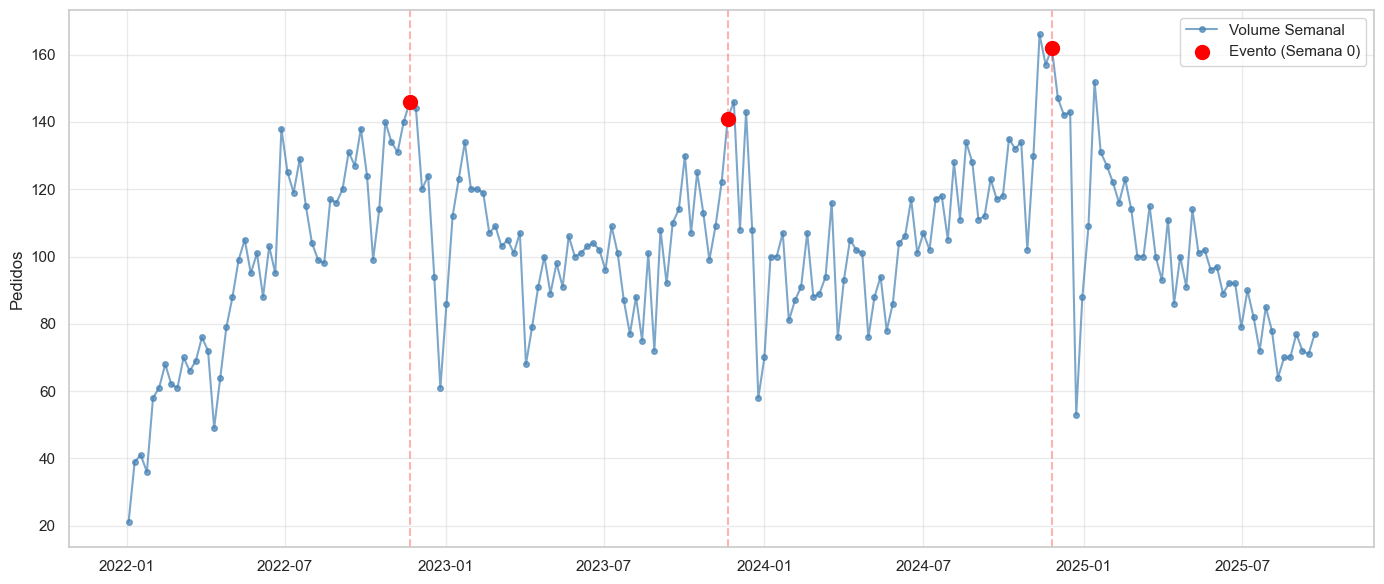

In [5]:
ft.plot_analisis_intervencion(df_input=df_global,
                              fechas_clave=fechas_bf)

**Nota**: Vemos a necesidade de plasmar o efecto do Black friday en semanas previas (seguramente 3) así como o impacto posterior (1-2 semanas). Como o modelo se axusta con variables dummys o efecto será o mesmo nos tres anos, co cal o modelo pode subestimar o pico de 2024 e sobreestimar o de 2022.

In [6]:
modelo = 'Global'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_global)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=2 
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q)X(P,D,Q)

Unha vez feita a análise de intervención, imos ver que modelo ARIMA se axusta mellor. Comezamos cunha interpretación gráfica para ter unha primeira idea.

#### Gráfico secuencial, fas e fap

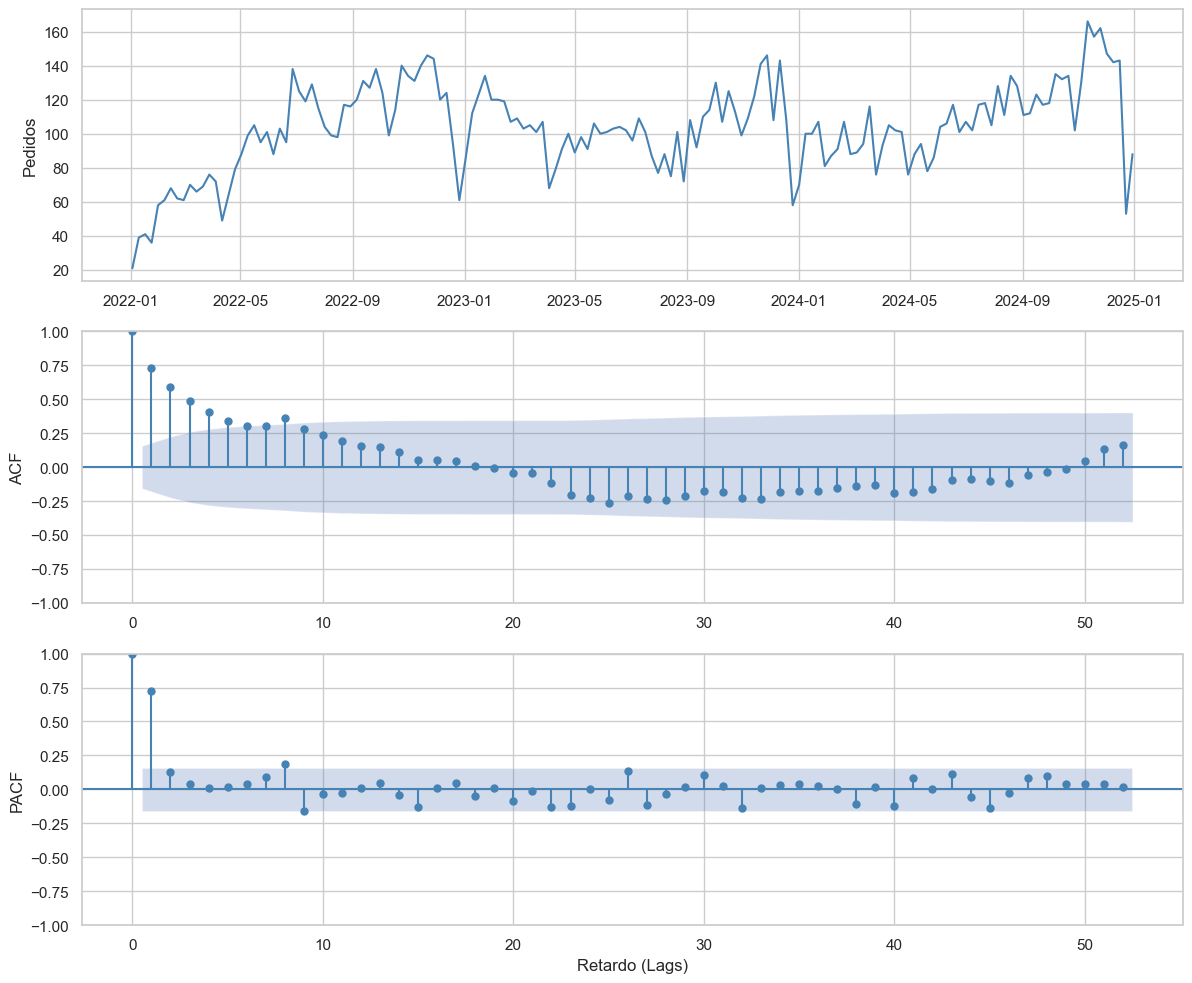

In [7]:
modelo = 'Global'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Observando as gráficas, non parece que telamos problema de heterocedasticidade. Ademáis, en contra do que podiamos supoñer (por ser datos medidos en varios anos), tampouco presenciamos estacionalidade (que se observaría na gráfica das fas unha forte correlación positiva no retardo estacional). O único a sinalar é unha lixeira tendencia positiva. Podemos daquela diferenciar a serie (d=1) e repetir os gráficos:

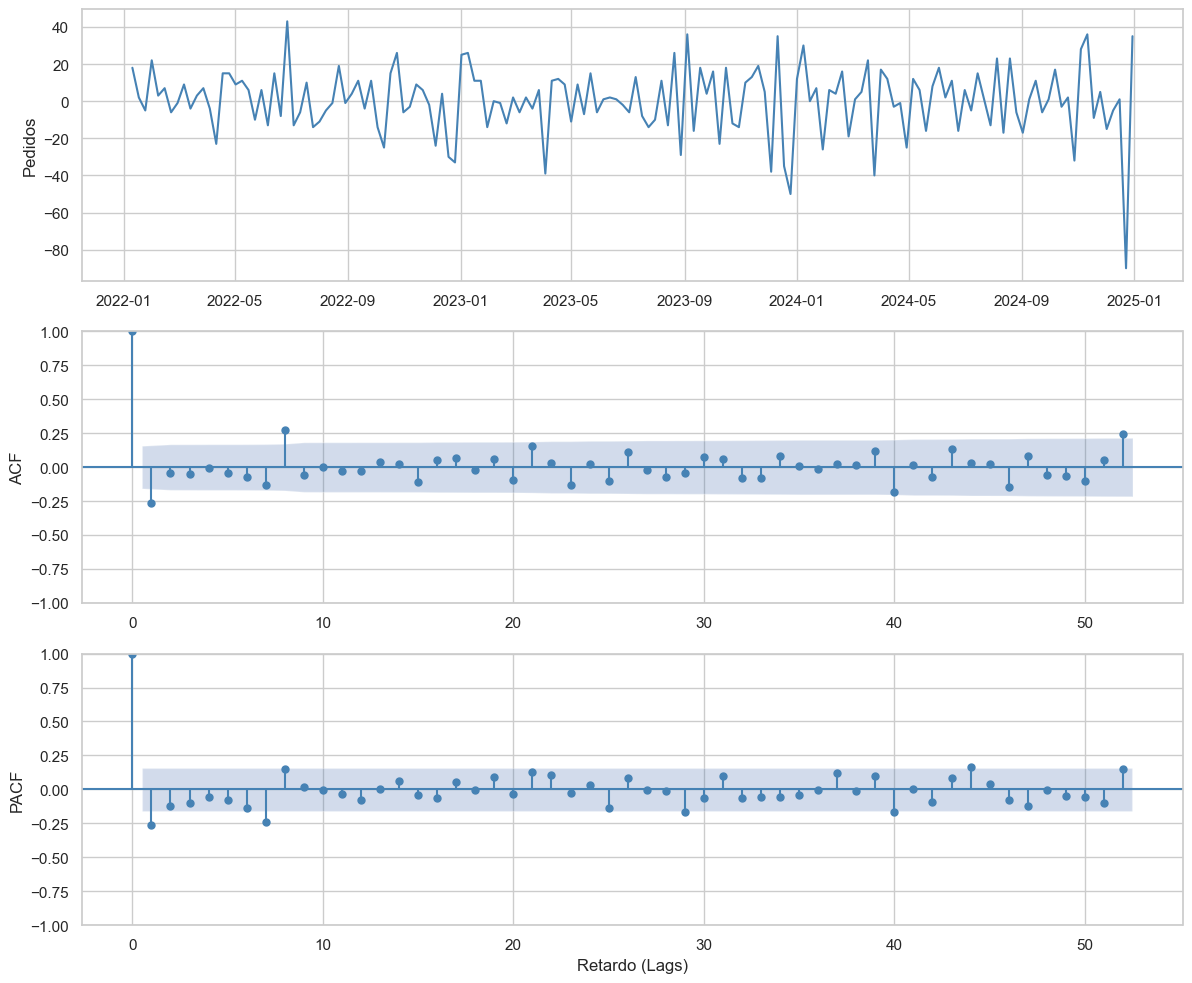

In [ ]:
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff,
    lags=52
)

Así, as gráficas suxiren que a serie diferenciada:
1. É estacionaria
2. Foi xerada por un proceso AR(1) ou MA(1).

Polo tanto, a serie orixinal parece compatible ou ben cun ARIMA(1,1,0) ou un ARIMA(0,1,1).

#### Selección do modelo mediante AIC

Unha vez proposto un primeiro modelo que poida explicar o comportamento da nosa serie, imos elixir o modelo que minimice o AIC:

In [9]:
modelo = 'Global'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1350.195, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1336.811, Time=0.28 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1327.110, Time=0.51 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1348.286, Time=0.60 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1326.141, Time=1.98 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1328.035, Time=1.70 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1328.074, Time=3.85 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1326.788, Time=2.40 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1334.606, Time=3.04 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1326.653, Time=2.35 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1325.080, Time=0.37 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1325.588, Time=0.40 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1334.927, Time=1.16 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AI

In [10]:
manual_order = (1, 1, 0)
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')
model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])

best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1334.927098449461


In [11]:
manual_order = (0, 1, 1)
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')
model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])

best_order = manual_order

print(f"Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

Modelo ARIMA (0, 1, 1) axustado correctamente.
AIC = 1325.5878636374523


Selecciónase o ARIMA(0,1,1)

In [12]:
print(model_manual.summary())
best_order = manual_order

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -657.794
Date:                Thu, 22 Jan 2026   AIC                           1325.588
Time:                        18:51:47   BIC                           1340.837
Sample:                    01-03-2022   HQIC                          1331.781
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre        20.3568      6.991      2.912      0.004       6.654      34.060
bf_peak       34.0691     13.697      2.487      0.013       7.224      60.914
bf_post       22.3554      5.306      4.213      0.0

Unha vez identificado o modelo debemos axustalo e ver se se detectan algúns atípicos.

#### Detección de atípicos (aditivos e innovativos)

Antes de facer o estudo dos residuos, estudemos a posible presenza de datos atípicos na serie de tempo. Existen dous tipos de atípicos: 
1. Atípicos Aditivos (AO): o valor da **serie** no isntante t=h foi xerado de forma distinta ao resto.
2. Atípicos Innovativos (IO): o valor da **innovación** no instante t=h  foi xerado de forma distinta ao resto.

In [13]:
modelo = 'Global'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y= datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    
    max_iter=10,    
    burn_in=3      
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order


 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.82 > 3.59
   [Iter 2] Detectado: 2023-12-25 | t-stat: 3.74 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.11). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.821211     1  Negativo
1 2023-12-25 -3.735505     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20231225
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Detectamos daquela 2 atípicos: na semana do 23-12-2024 e na semana de 25-12-2023. A maneira de proceder será incluír o impacto de atípico con menor p-valor (o de estatístico máis grande en valor absoluto) mediante unha variable dummy (variable que toma o valor 1 no intre t=h e 0 no resto de casos) e axustamos un novo modelo incluíndo dita variable como variable exóxena:

#### Estimación ou axuste do modelo

In [14]:
modelo = 'Global'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima['Global']['X_train_final'].shape[1]} variables exóxenas...")

model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],       
    order=datos_arima[modelo]['order'],         
    trend='n',               
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

#  Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(0, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -634.506
Date:                Thu, 22 Jan 2026   AIC                           1283.011
Time:                        18:52:37   BIC                           1304.270
Sample:                    01-03-2022   HQIC                          1291.646
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              17.0100      5.987      2.841      0.004       5.277      28.744
bf_peak             28.9619     11.723      

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fixado un nivel de significación do 5% o termo correspondente ao efecto pre-black_friday non sería significativo. Porén, como só dispoñemos de 3 anos de histórico, pode ser que o efecto captado por dita variable non sexa moi significativo mais non o eliminaremos do modelo.

Vemos como todos os coeficientes do modelo son significativos. Pasamos entón a facer a análise dos residuos e validar o modelo.

#### Diagnose ou análise dos residuos

Imos comprobar as hipóteses do modelo e ver así se o modelo axustado é válido. 
A hipótese fundamental a contrastar é a que esixe que as onnovacións $\{a_t\}$ sexan ruído blanco, isto é:
1. Media cero
2. Homocedasticidade
3. Incorreladas

Graficamente:

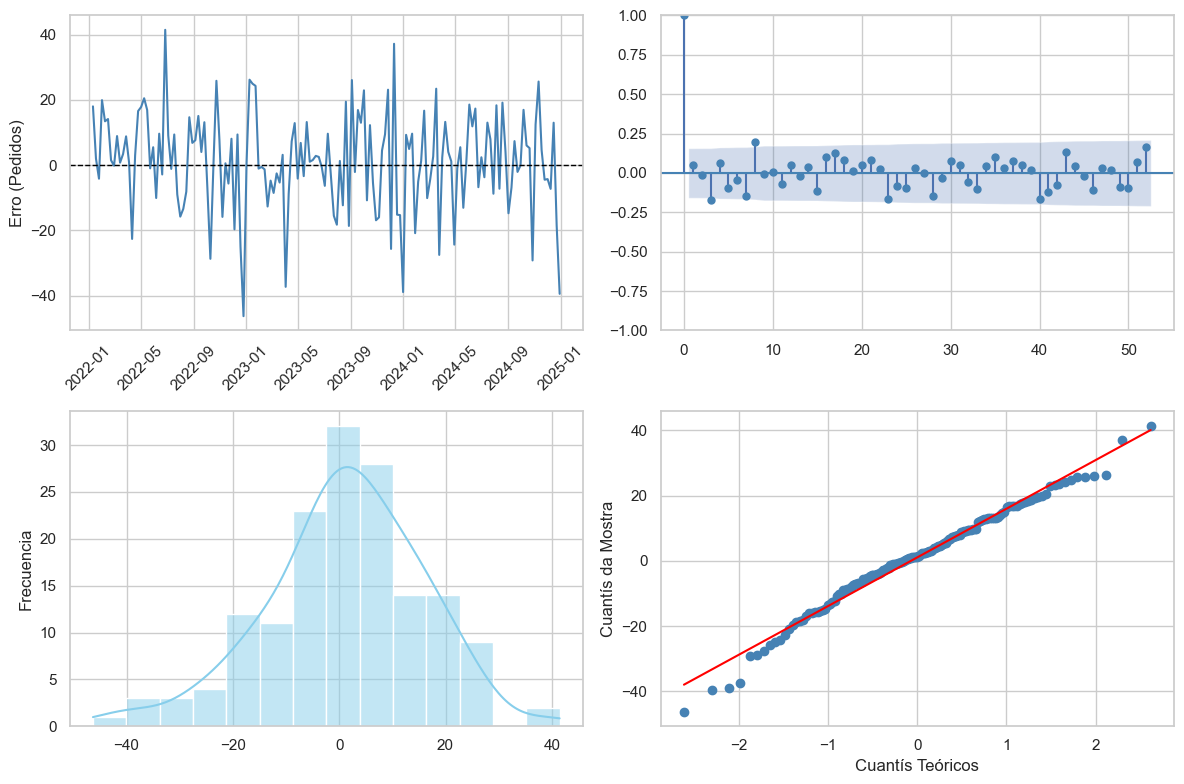


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.3700
  Normalidade (Shapiro): p-value = 0.0909
------------------------------------------------------------


In [15]:
ft.analizar_residuos_arima(modelo_final,lags=52)

In [16]:
print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -634.506
Date:                Thu, 22 Jan 2026   AIC                           1283.011
Time:                        18:52:49   BIC                           1304.270
Sample:                    01-03-2022   HQIC                          1291.646
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              17.0100      5.987      2.841      0.004       5.277      28.744
bf_peak             28.9619     11.723      2.470      0.013       5.985      51.939
bf_post             15.8726 

#### Predicións

---  VALIDACIÓN ROLLING WINDOW: Global ---
   Variables en modelo: 5
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
 Iniciando Rolling Window ARIMAX (38 semanas)...


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   > Semana 10/38: Pred=110.54


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 20/38: Pred=102.24


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 30/38: Pred=79.61


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

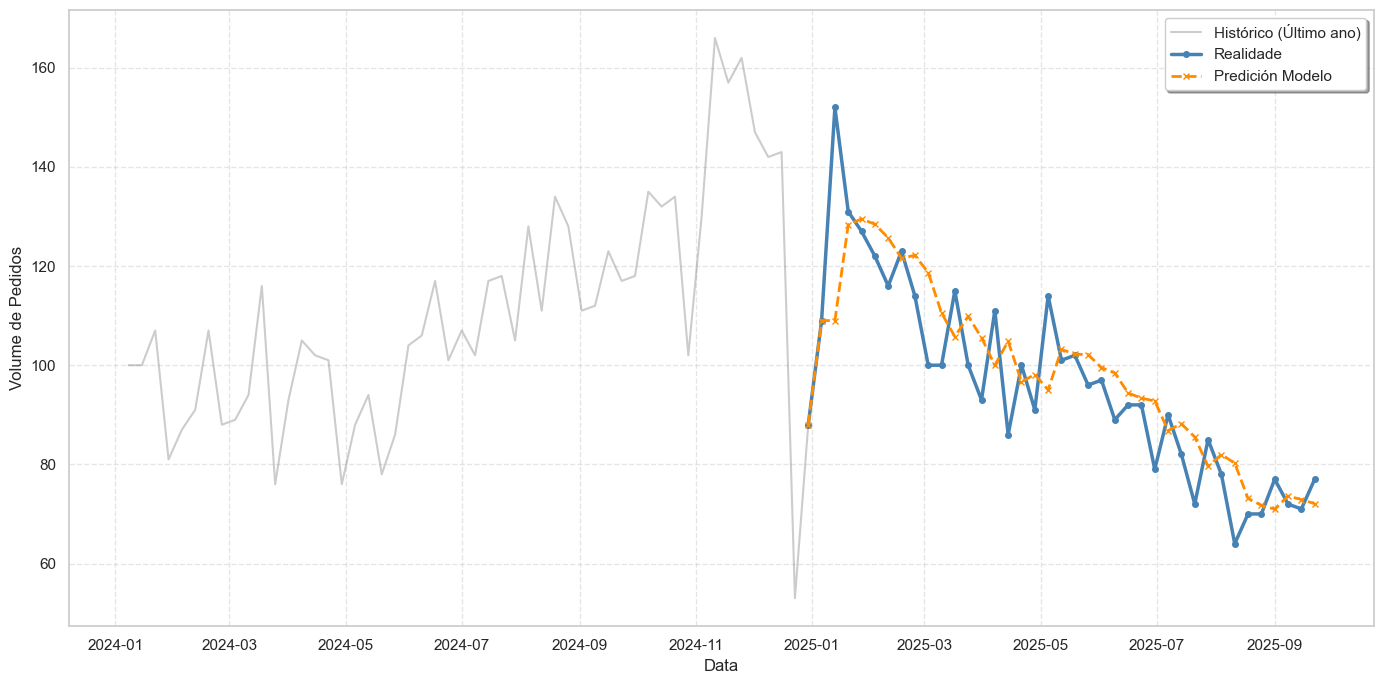

In [17]:
modelo = 'Global'
print(f"---  VALIDACIÓN ROLLING WINDOW: {modelo} ---")

datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True           
)

datos_arima[modelo]['predicions'] = preds_rolling

ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

Para avaliar o rendemento do modelo, imos calcular varias medidas do erro, é dicir, imos calcular o erro das predicións con respecto aos datos reais (datos de test):

In [18]:
modelo = 'Global'
# CÁLCULO DE MÉTRICAS
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- AVALIACIÓN: Global (Rolling) ---
MAE:  7.90
RMSE: 11.15
MAPE: 8.18%
MASE: 0.60 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Agora gardamos a información deste modelo para empregar no modelo Prophet:

In [19]:
modelo = 'Global'

if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"---  GARDADO FINAL PARA PROPHET: {modelo} ---")

df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

export_para_prophet[modelo] = df_prophet

print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

---  GARDADO FINAL PARA PROPHET: Global ---
    Empaquetando datos de Global para Prophet...

 Datos exportados para Global.
   Dimensións: (195, 7)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_pre  bf_peak  bf_post  outlier_20241223  \
190 2025-08-25         70       0        0        0                 0   
191 2025-09-01         77       0        0        0                 0   
192 2025-09-08         72       0        0        0                 0   
193 2025-09-15         71       0        0        0                 0   
194 2025-09-22         77       0        0        0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Modelo por cluster

### Cluster 1

Comezamos polo primeiro cluster, que estaba formado polos clientes dos sectores de transporte, retail e electrónica.

In [20]:
df_cluster_1 = datos['Cluster 1'].set_index('semana')

#### Análise de intervención: Black Friday

Repetimos o procedemento anterio neste caso para os clientes do cluster 1.

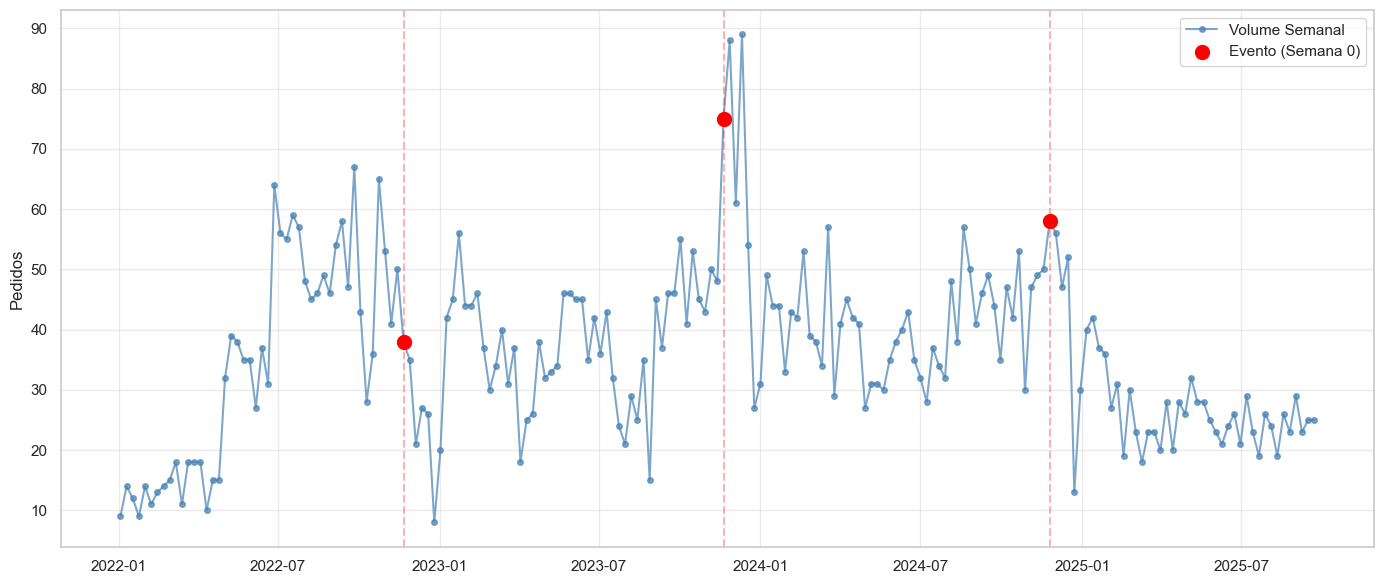

In [21]:
ft.plot_analisis_intervencion(df_input=df_cluster_1,
                              fechas_clave=fechas_bf)

Aquí vemos como o efecto do Black-Friday cambia drasticamente. Por unha parte, non parece apreciarse efecto previo á semana do evento (en particular no 2022 vese caída nas semanas previas). Ademáis, o efecto nas semanas posteriores é de caída nos anos 2022 e 2024 mentres que no 2023 si provoca un pico. Suxerencia: modelar o efecto do B-F con tres variables dummy que capten o efecto da semana anterior, a do propio evento e a posterior.

In [22]:
modelo = 'Cluster 1'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_1)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

Comezamos pola interpretación gráfica:

#### Gráfico secuencial, fas e fap

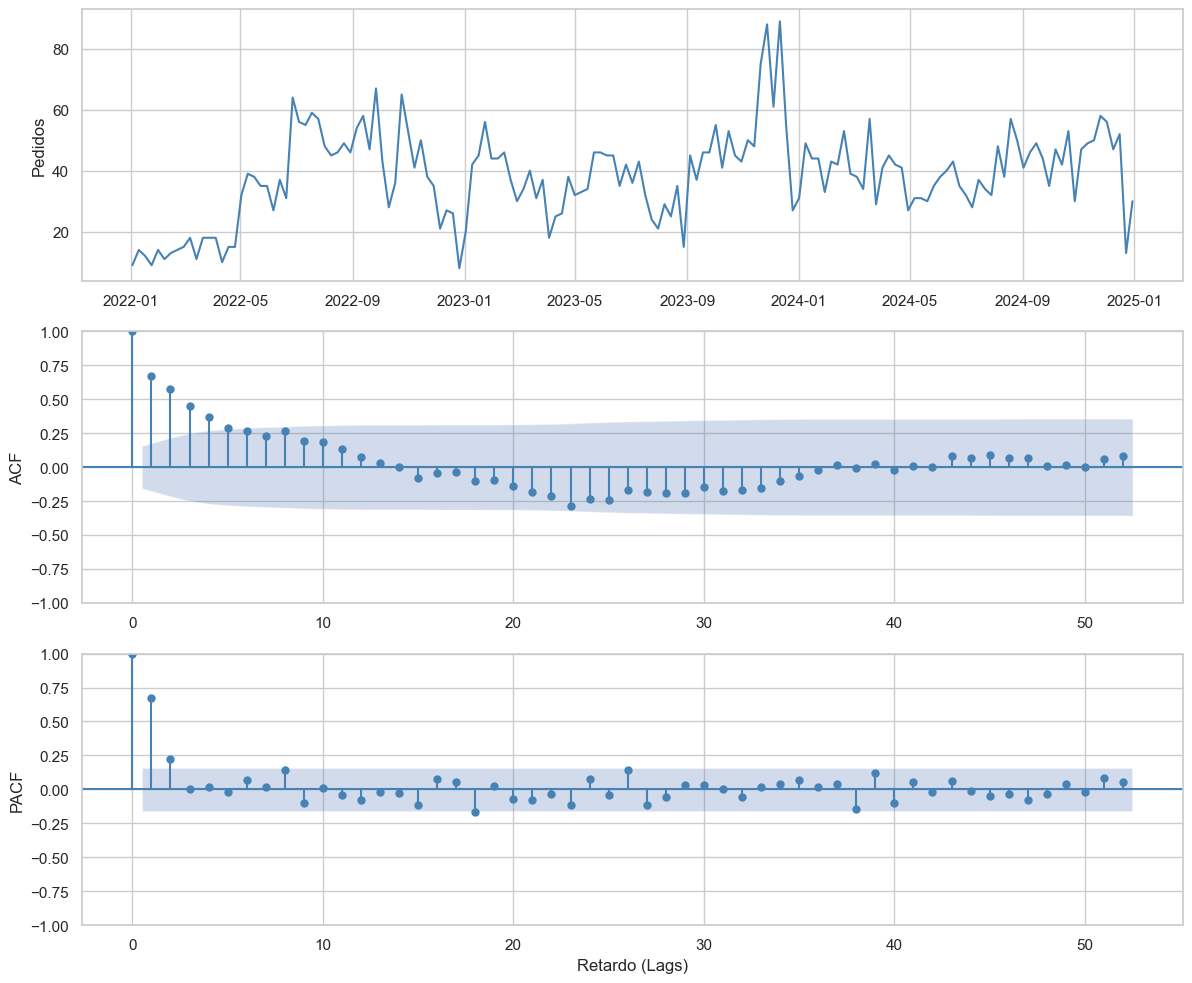

In [23]:
modelo = 'Cluster 1'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

De forma similar ao caso anterior, non observamos nin problemas de heterocedasticidade nin estacionalidade (gráfico secuencial e fas mostrais respectivamente). Porén, o único a sinalar sería unha certa tendencia positiva que podemos correxir aplicando unha diferencia regular (d=1) e repetindo os gráficos.

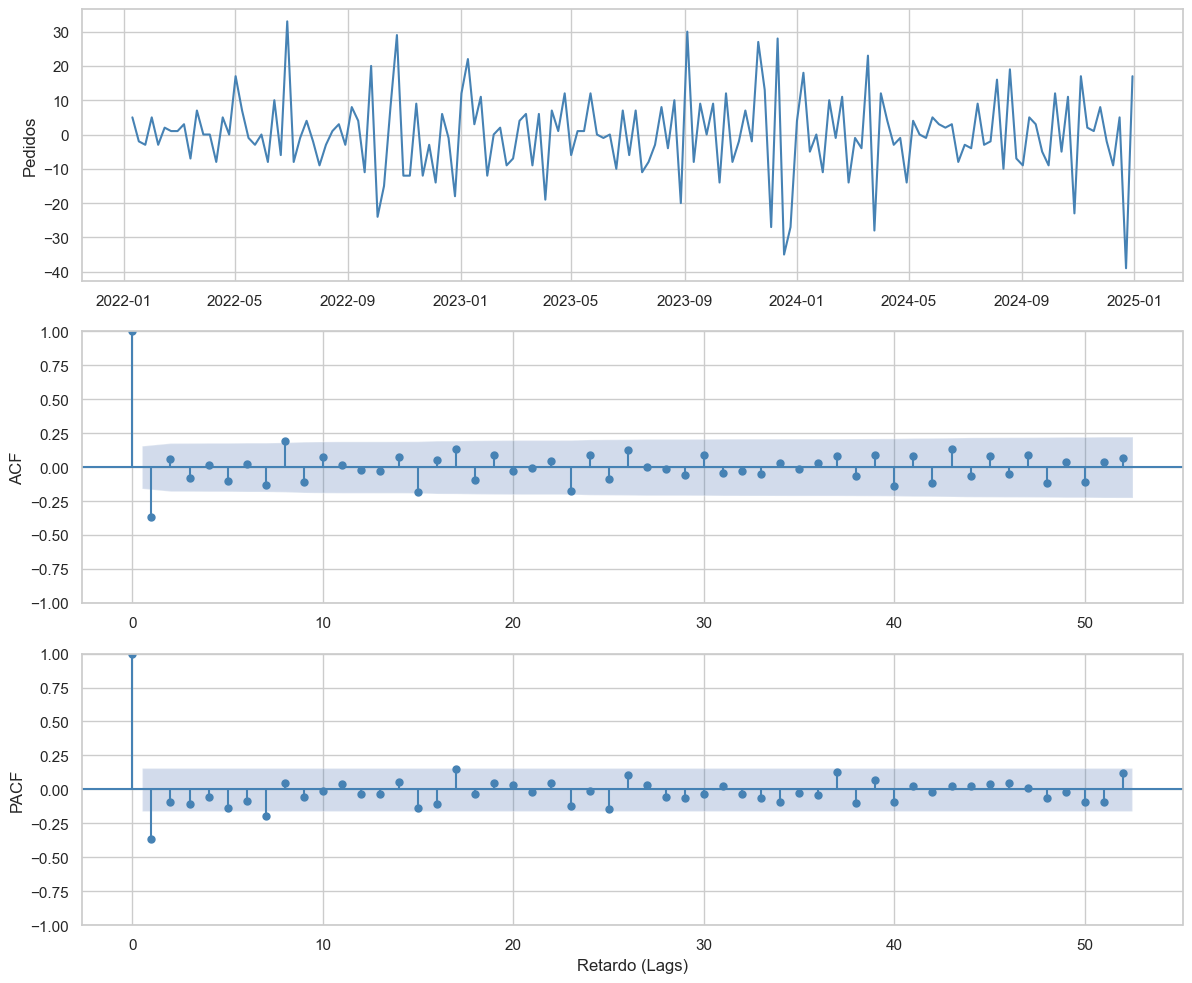

In [24]:
modelo = 'Cluster 1'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Unha vez diferenciada a serie, o gráfico secuencial e as fas e fap mostrais suxiren:
1. Serie estacionaria
2. Foi xerada por un MA(1) ou ben AR(1)

Polo tanto, a serie orixinal pode ser compatible cun ARIMA(1,1,0) ou ben ARIMA(0,1,1).

#### Selección do modelo mediante AICc

Unha vez suxerido un modelo que poida explicar a nosa serie, imos seleccionar aquel que minimiza o AIC

In [25]:
modelo = 'Cluster 1'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1212.044, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1192.155, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1186.562, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1210.065, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1185.673, Time=0.32 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.62 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.83 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1187.016, Time=0.43 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1192.152, Time=0.51 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1186.000, Time=0.49 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1183.948, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1184.645, Time=1.79 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1190.179, Time=0.27 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1184.061

In [26]:
modelo = 'Cluster 1'

manual_order = (0, 1, 1)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (0, 1, 1) axustado correctamente.
AIC = 1184.6449757991013


In [27]:
modelo = 'Cluster 1'

manual_order = (1, 1, 0)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1190.1790246533055


In [28]:
manual_order = (0,1,1)
print(model_manual.summary())
best_order = manual_order

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -590.090
Date:                Thu, 22 Jan 2026   AIC                           1190.179
Time:                        18:57:55   BIC                           1205.428
Sample:                    01-03-2022   HQIC                          1196.373
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre         2.2545     12.045      0.187      0.852     -21.353      25.862
bf_peak       10.7478      7.442      1.444      0.149      -3.837      25.333
bf_post       11.7301      7.971      1.472      0.1

#### Detección de atípicos (aditivos e innovativos)

In [29]:
modelo = 'Cluster 1'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    
    max_iter=10,    
    burn_in=3      
)
print(df_outliers)
print(X_train_con_outliers.head(5))


if 'datos_arima_final' not in locals():
    datos_arima_final = {}

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Non se atoparon máis atípicos significativos (Max t: 3.58). Fin.
    Non se atoparon outliers.
Empty DataFrame
Columns: [fecha, t_stat, iter, tipo]
Index: []
            bf_pre  bf_peak  bf_post
semana                              
2022-01-03       0        0        0
2022-01-10       0        0        0
2022-01-17       0        0        0
2022-01-24       0        0        0
2022-01-31       0        0        0


Non se atoparon atípicos.

#### Estimación ou axuste do modelo

Unha vez visto que non se detectan atípicos, axustemos o modelo e vexamos se todos os coeficientes son significativos ou non:

In [30]:
modelo = 'Cluster 1'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       
    order = datos_arima[modelo]['order'],        
    trend ='n',               
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

# Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(0, 1, 1) con 3 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -580.602
Date:                Thu, 22 Jan 2026   AIC                           1171.205
Time:                        18:58:39   BIC                           1186.390
Sample:                    01-03-2022   HQIC                          1177.373
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre         3.8554     12.157      0.317      0.751     -19.972      27.683
bf_peak       12.1533      6.399      1.899      0.058      -0

Vemos como o efecto do pre-Black-Friday non é nada significativo (p-valor = 0.76). Polo tanto pasaremos a axustar o modelo sen dita variable dummy.

In [31]:
modelo = 'Cluster 1'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado



print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
 Variable 'bf_pre' eliminada correctamente das matrices.
 Reaxustando SARIMAX(0, 1, 1) coas 2 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -580.842
Date:                Thu, 22 Jan 2026   AIC                           1169.685
Time:                        18:59:10   BIC                           1181.833
Sample:                    01-03-2022   HQIC                          1174.619
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_peak       10.9096      3.904   

Vemos como agora todos os coeficientes son significativos.

#### Diagnose ou análise dos residuos

Imos comprobar as hipóteses do modelo e ver así se o modelo axustado é válido. 
A hipótese fundamental a contrastar é a que esixe que as innovacións $\{a_t\}$ sexan ruído blanco, isto é:
1. Media cero
2. Homocedasticidade
3. Incorreladas

Graficamente:

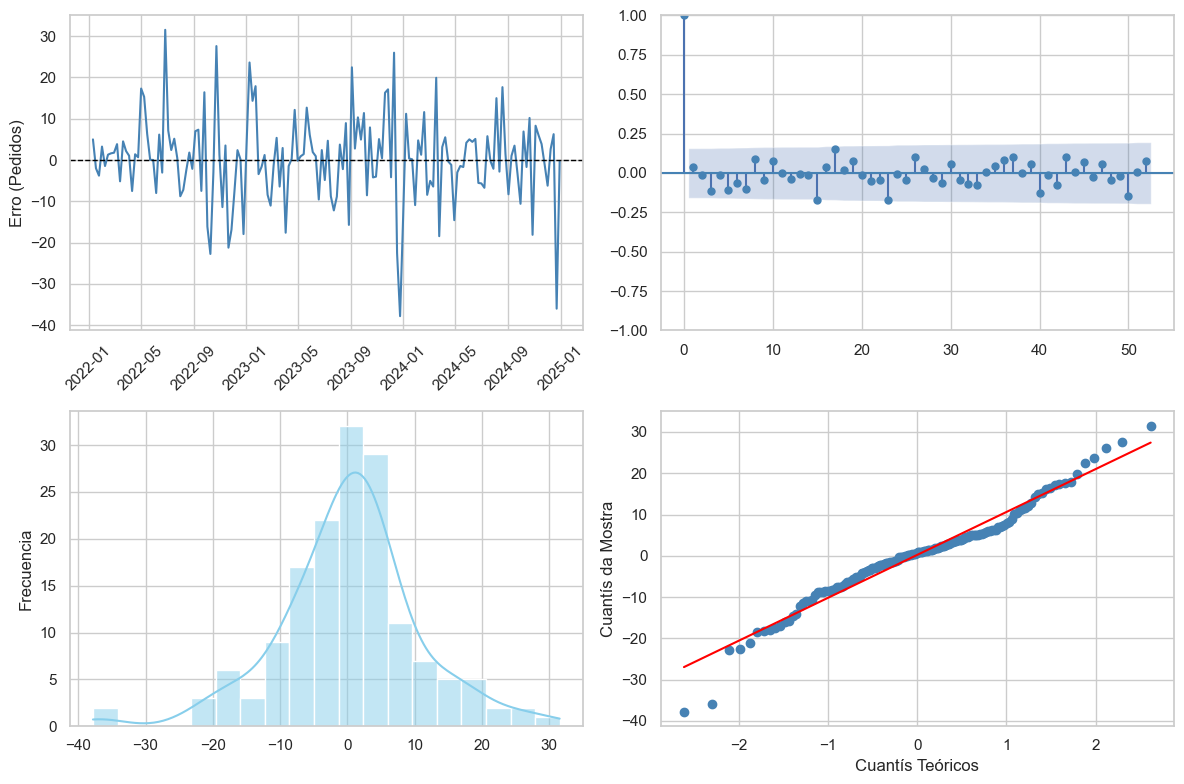


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.7809
  Normalidade (Shapiro): p-value = 0.0006
------------------------------------------------------------


In [32]:
ft.analizar_residuos_arima(modelo_final,lags=52)

In [33]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -580.842
Date:                Thu, 22 Jan 2026   AIC                           1169.685
Time:                        19:03:28   BIC                           1181.833
Sample:                    01-03-2022   HQIC                          1174.619
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_peak       10.9096      3.904      2.794      0.005       3.257      18.562
bf_post       14.6116      4.420      3.306      0.001       5.949      23.274
ma.L1         -0.4801      0.068     -7.010      0.000      -0.614      -0.346
sigma2       110.5210      9.272     11.920      0.000      92.349     128.693
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                21.32
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               0.75   Skew:                            -0.25
Prob(H) (two-sided):                  0.30   Kurtosis:                         4.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Predicións

--- VALIDACIÓN ROLLING WINDOW: Cluster 1 ---
   Variables en modelo: 2
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=25.25
   > Semana 20/38: Pred=28.43
   > Semana 30/38: Pred=21.69


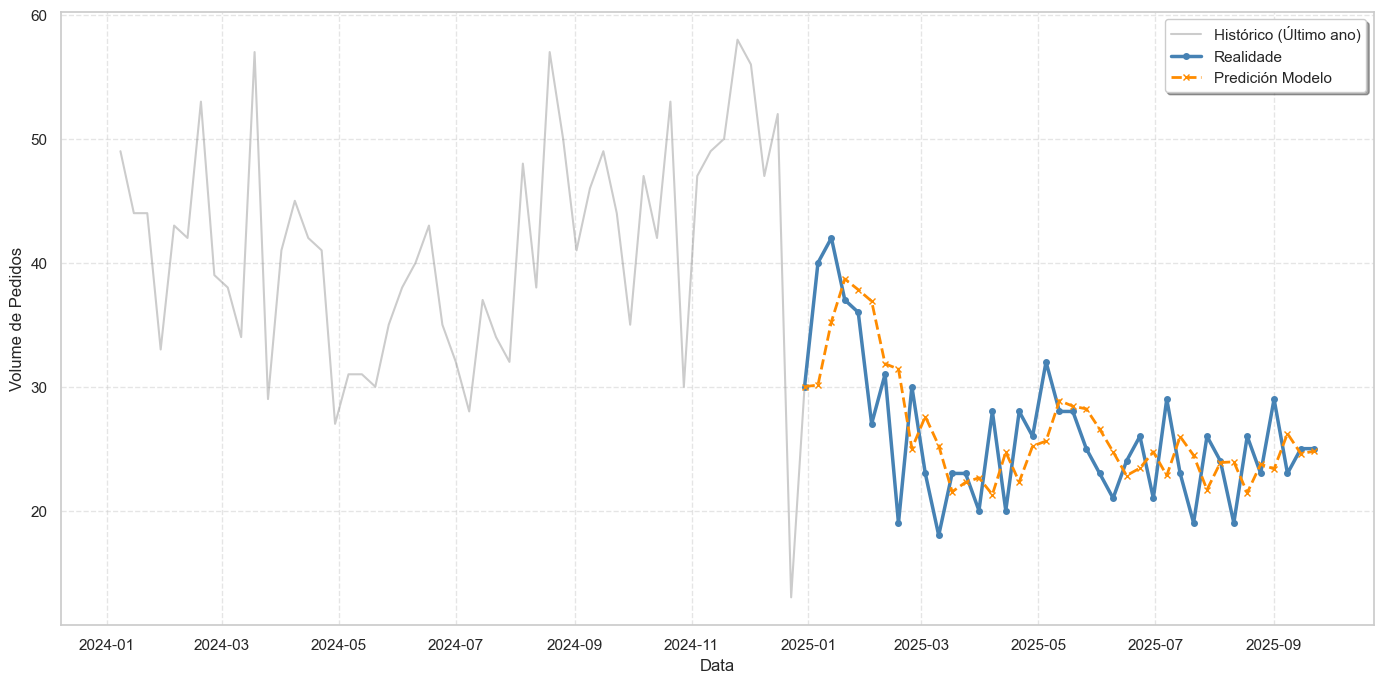

In [34]:
modelo = 'Cluster 1'
print(f"--- VALIDACIÓN ROLLING WINDOW: {modelo} ---")


datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True          
)

datos_arima[modelo]['predicions'] = preds_rolling

ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [35]:
modelo = 'Cluster 1'
# CÁLCULO DE MÉTRICAS

metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- AVALIACIÓN: Cluster 1 (Rolling) ---
MAE:  3.88
RMSE: 4.85
MAPE: 15.57%
MASE: 0.45 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Gardamos a información de atípicos e análise de intervención para empregar no Prophet:

In [36]:
modelo = 'Cluster 1'

if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- GARDADO FINAL PARA PROPHET: {modelo} ---")


df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- GARDADO FINAL PARA PROPHET: Cluster 1 ---
    Empaquetando datos de Cluster 1 para Prophet...

 Datos exportados para Cluster 1.
   Dimensións: (195, 4)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_peak', 'bf_post']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_peak  bf_post
190 2025-08-25         23        0        0
191 2025-09-01         29        0        0
192 2025-09-08         23        0        0
193 2025-09-15         25        0        0
194 2025-09-22         25        0        0


### Cluster 2

Pasamos agora a axustar un modelo ARIMA para o cluster formado polos clientes de paquetería e froita.

In [37]:
df_cluster_2 = datos['Cluster 2'].set_index('semana')

#### Análise de intervención: Black Friday

Novamente repetimos a análise do impacto do Black Friday, agora sobre os clientes do segundo cluster.

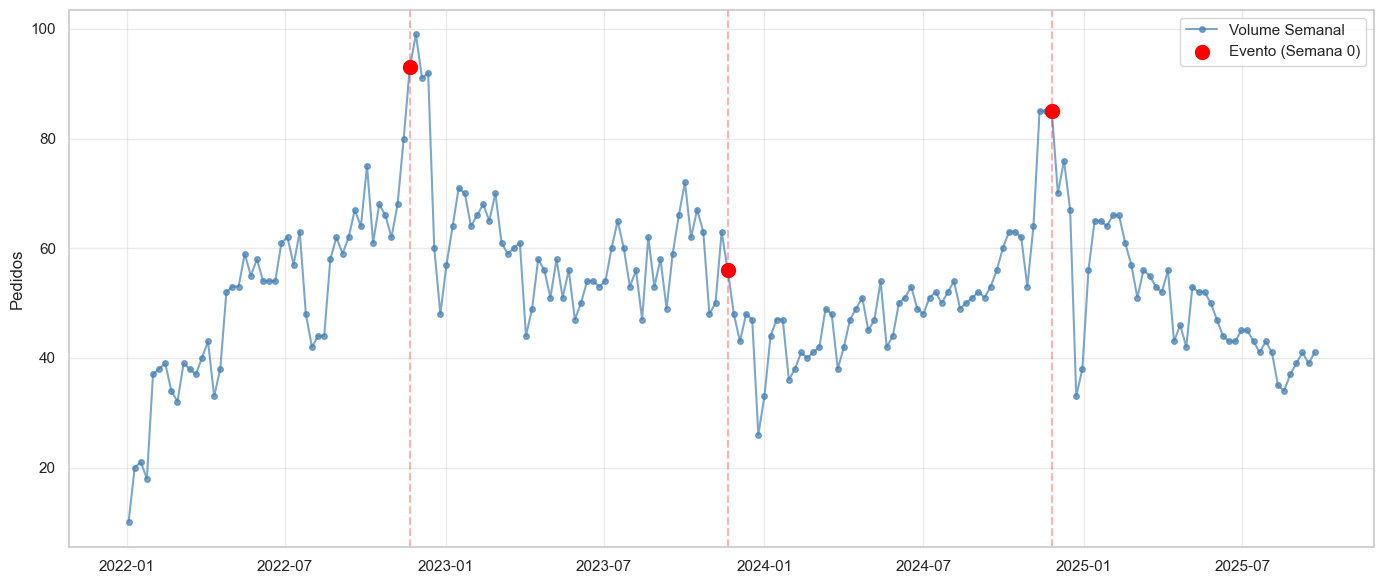

In [38]:
ft.plot_analisis_intervencion(df_input=df_cluster_2,
                              fechas_clave=fechas_bf)

Graficamente, vemos como o efecto previo do B-F se extende pricipalmente ás dúas semanas anteriores (sobre todo no 2022 e 2024). Ademáis, no 2022 observamos como o pico se exntende unha semana e despois cae, mentres uqe no 2023 e 2024 cae na seguinte semana (no 2023 en particular é maior o efecto na semana previa ca na propia semana do evento). 

Así, decidimos modelar o efecto do B-F con 3 variables dummys. Aprimeira plasmará o efecto das dúas semanas previas, a segunda a da propia semana e a última o efecto da semana posterior.

In [39]:
modelo = 'Cluster 2'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_2)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap

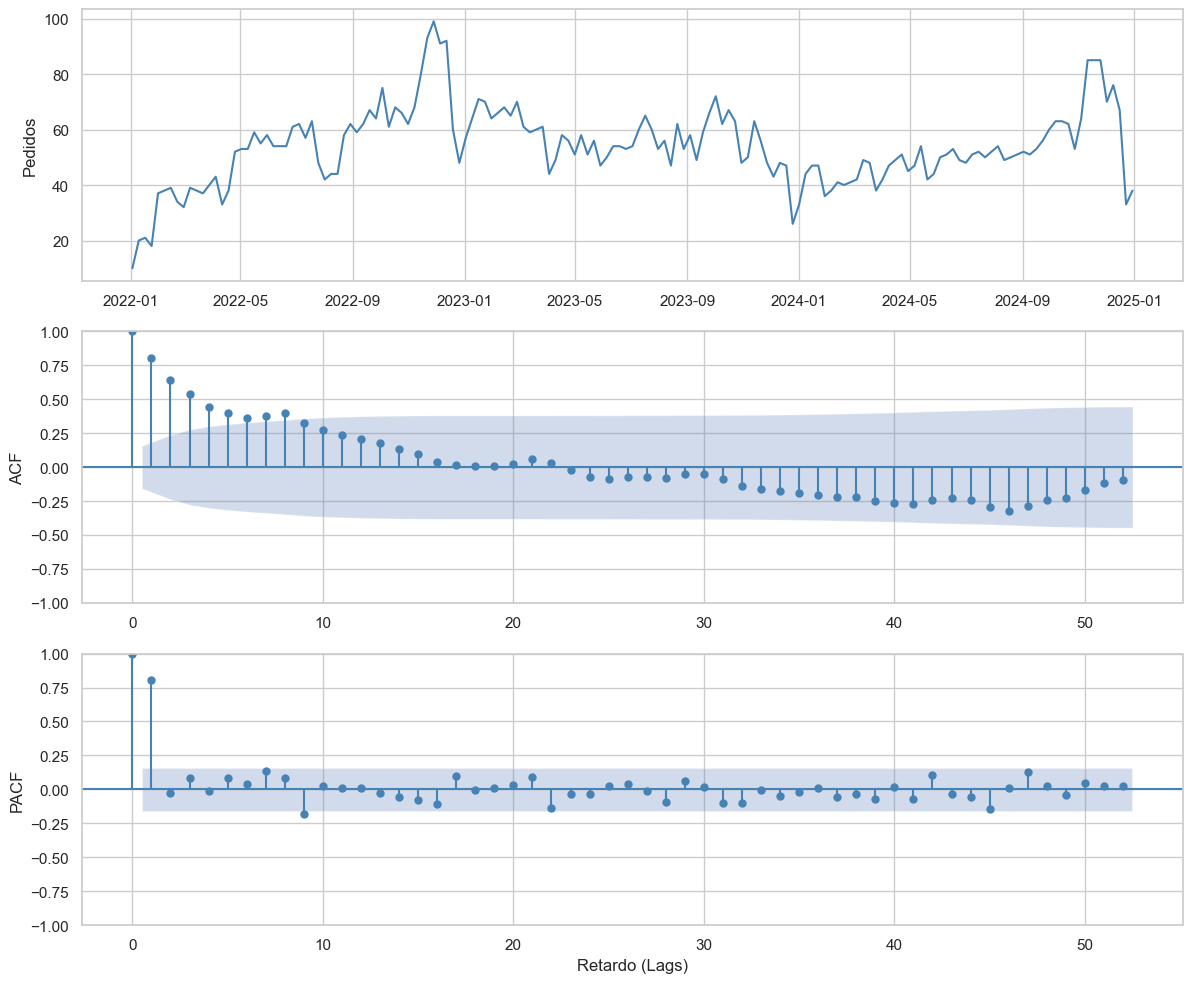

In [40]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Observando o gráfico secuencial e a fas mostral, podemos intuir a presenza de tendencia. Polo tanto, podemos pensar en repetir os gráficos unha vez diferenciada a serie.

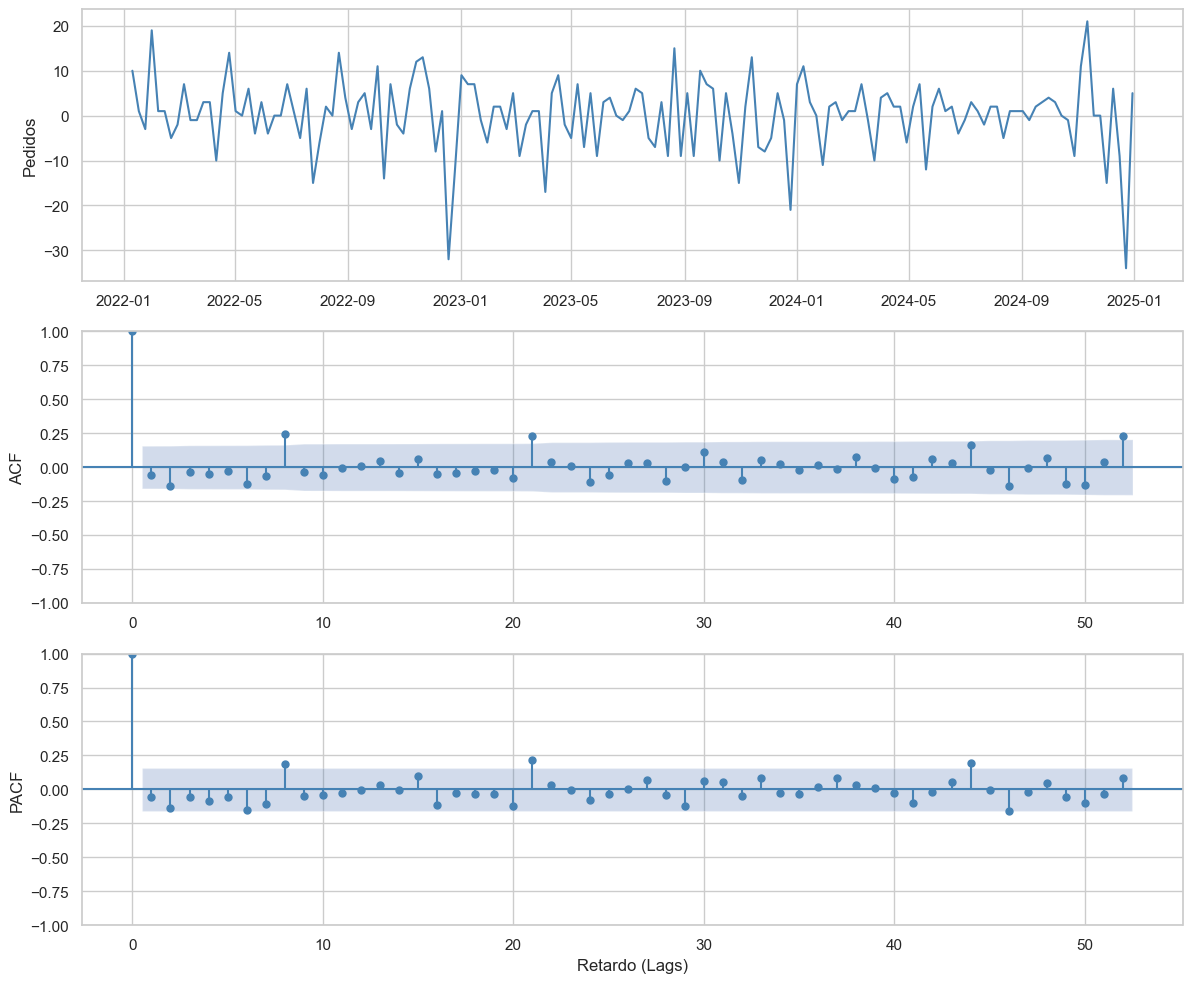

In [41]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Unha vez diferenciada a serie, non se observan problemas de estacionalidade nin heterocedasticidade. Ademáis, observando os gráficos das fas e fap mostrais podemos suxerir un ARMA(0,0) para a serie diferenciada. Daquela, para a serie orixinal poderiamos suxerir un ARIMA(0,1,0)

#### Selección do modelo mediante AICc

In [42]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1692.920, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1098.826, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1099.988, Time=0.21 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1099.570, Time=0.16 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1089.669, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1252.527, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1091.669, Time=0.23 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1091.671, Time=0.17 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1159.580, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.21 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 1.587 seconds
                               SARIMAX Resul

Segundo o criterio do AIC, o mellor modelo sería un ARIMA(1,0,0) con intercepto. Este modelo presenta un AIC = 1089.67.

Recordemos que segundo o criterio gráfico seleccionariamos un ARIMA(0,1,0), vexamos cal é o AIC deste modelo:

In [43]:
modelo = 'Cluster 2'

manual_order = (0, 1, 0)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (0, 1, 0) axustado correctamente.
AIC = 1087.6006523616772


O algoritmo non detecta a tendencia. Obrigamos a que diferencie $(d=1)$:

In [44]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d=1
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1089.516, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1090.556, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1090.092, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1087.601, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1083.285, Time=0.16 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1082.829, Time=0.25 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1087.437, Time=0.18 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1084.713, Time=0.27 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1083.347, Time=0.33 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1083.091, Time=0.26 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=1087.044, Time=0.25 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1086.108, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1081.496, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1

Daquela agora o mellor modelo sería un ARIMA(2,1,1) cun AIC = 1081.50.

In [45]:
best_order = modelo_global.order

#### Detección de atípicos (aditivos e innovativos)

Pasamos agora á detección de outliers mediante a función que definimos no primeiro modelo axustado:

In [46]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    
    max_iter=10,    
    burn_in=3      
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.40 > 3.59


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   [Iter 2] Detectado: 2022-12-19 | t-stat: 3.65 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.07). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.403763     1  Negativo
1 2022-12-19 -3.654433     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20221219
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


Detectamos dous atípicos correspondentes coas semanas do 23-12-2024 e a semana do 19-12-2022. Engadímolos ao modelo como variables dummy.

#### Estimación ou axuste do modelo

Axustamos o modelo resultante e vemos se os seus parámetros son significativos ou non.

In [47]:
modelo = 'Cluster 2'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")


model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],      
    order = datos_arima[modelo]['order'],         
    trend ='n',                
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

# Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(2, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -518.644
Date:                Thu, 22 Jan 2026   AIC                           1055.288
Time:                        19:06:37   BIC                           1082.621
Sample:                    01-03-2022   HQIC                          1066.391
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              10.6806      2.909      3.671      0.000       4.978      16.383
bf_peak             12.1994      3.598      

Vemos como o efecto de $\varphi_2$ non é significativo (ten unp-valor de 0.318). Axustamos o modelo sen dito parámetro, é dicir, un ARIMA(1,1,1):

In [48]:
modelo = 'Cluster 2'
best_order = (1,1,1)
datos_arima[modelo]['order'] = best_order
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")


model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],      
    order = datos_arima[modelo]['order'],         
    trend ='n',                
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

# Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(1, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -518.180
Date:                Thu, 22 Jan 2026   AIC                           1052.359
Time:                        19:06:58   BIC                           1076.655
Sample:                    01-03-2022   HQIC                          1062.228
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               9.6644      2.792      3.461      0.001       4.192      15.137
bf_peak             10.9817      3.216      

Agora vemos como o parámetro menos significativo é o correspondente á parte de medias móviles $\theta_1$. Axustemos logo un ARIMA(1,1,0):

In [49]:
modelo = 'Cluster 2'
best_order = (1,1,0)
datos_arima[modelo]['order'] = best_order
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],      
    order = datos_arima[modelo]['order'],         
    trend ='n',                
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

#  Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(1, 1, 0) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -527.114
Date:                Thu, 22 Jan 2026   AIC                           1068.228
Time:                        19:07:22   BIC                           1089.532
Sample:                    01-03-2022   HQIC                          1076.881
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               8.8366      3.083      2.866      0.004       2.793      14.880
bf_peak             10.2400      3.978      

Agora o non significativo é o correspondente á parte autorregresiva ($\varphi_1$):

In [50]:
modelo = 'Cluster 2'
best_order = (0,1,0)
datos_arima[modelo]['order'] = best_order
print(f"Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       
    order = datos_arima[modelo]['order'],         
    trend ='n',               
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

# Mostramos a táboa de significación
print(modelo_final.summary())

Axustando modelo final SARIMAX(0, 1, 0) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -527.402
Date:                Thu, 22 Jan 2026   AIC                           1066.805
Time:                        19:07:42   BIC                           1085.065
Sample:                    01-03-2022   HQIC                          1074.222
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               8.7500      3.289      2.660      0.008       2.304      15.196
bf_peak              9.8333      3.963      2

Vemos como o efecto post-bf non é significativo (p-valor = 0.407). Daquela podemos eliminalo do modelo e reaxustar.

In [52]:
modelo = 'Cluster 2'
print("Aplicando 'Backward Elimination': Eliminando 'bf_post'...")


variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

print(modelo_final.summary())

Aplicando 'Backward Elimination': Eliminando 'bf_post'...
A variable 'bf_post' non se atopou (quizais xa a borraste).
 Reaxustando SARIMAX(0, 1, 0) coas 4 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -527.801
Date:                Thu, 22 Jan 2026   AIC                           1065.602
Time:                        19:08:10   BIC                           1080.819
Sample:                    01-03-2022   HQIC                          1071.783
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              

Vemos agora como todos os coeficientes son significativos. Temos daquela axustado o modelo.

#### Diagnose ou análise dos residuos

Graficamente:

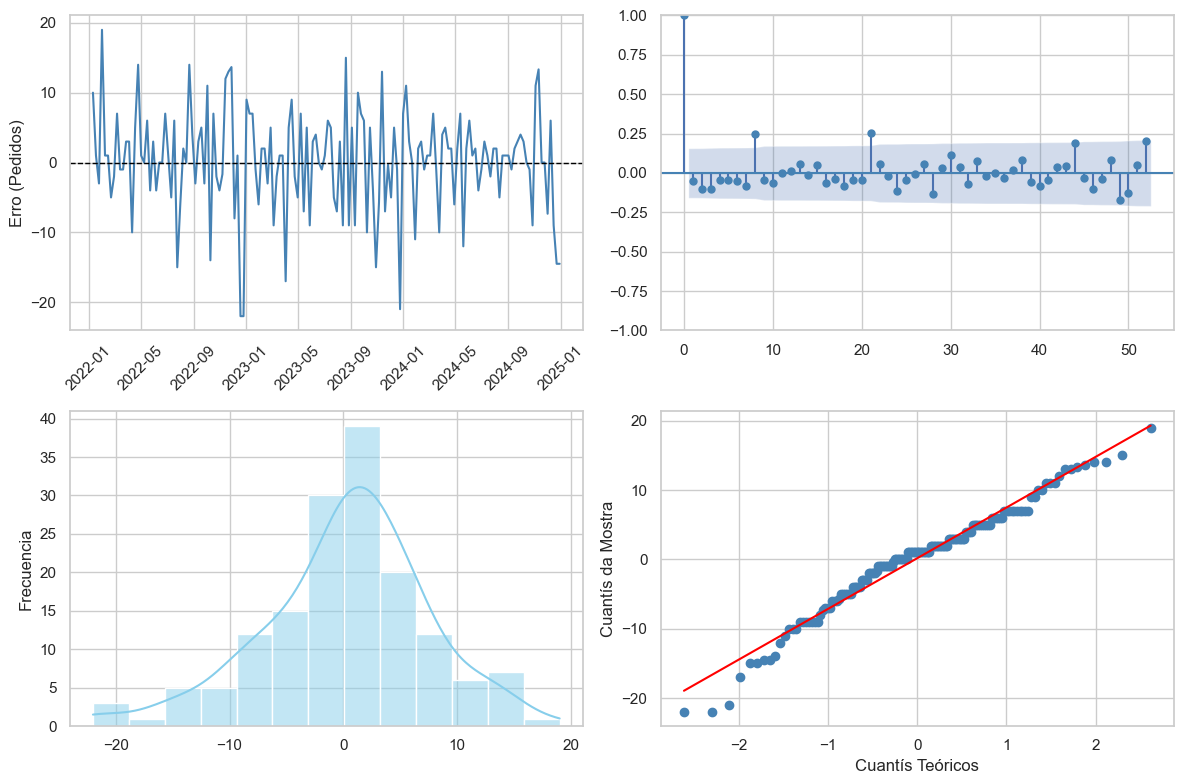


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.7601
  Normalidade (Shapiro): p-value = 0.0044
------------------------------------------------------------


In [53]:
ft.analizar_residuos_arima(modelo_final,lags=52)

In [54]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -527.801
Date:                Thu, 22 Jan 2026   AIC                           1065.602
Time:                        19:08:24   BIC                           1080.819
Sample:                    01-03-2022   HQIC                          1071.783
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               7.6667      2.937      2.610      0.009       1.910      13.423
bf_peak              7.6667      2.846      2.694      0.007       2.089      13.245
outlier_20241223   -19.5000      2.590     -7.528      0.000     -24.577     -14.423
outlier_20221219   -10.0000      1.707     -5.858      0.000     -13.346      -6.654
sigma2              53.1148      5.189     10.235      0.000      42.944      63.286
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):                 9.63
Prob(Q):                              0.49   Prob(JB):                         0.01
Heteroskedasticity (H):               0.51   Skew:                            -0.49
Prob(H) (two-sided):                  0.02   Kurtosis:                         3.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Cuidado** non se cumpre a hipótese da homocedasticidade. Temos un p-valor no test de Homocedasticidade de 0.02 < 0.05, co cal debemos reaxustar o modelo.

#### Corrección da heterocedasticidade

Aplicaremos unha transformación logarítmica aos nosos datos e repetiremos o procedemento.

In [55]:
modelo = 'Cluster 2'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

**Selección das ordes (p,d,q)**

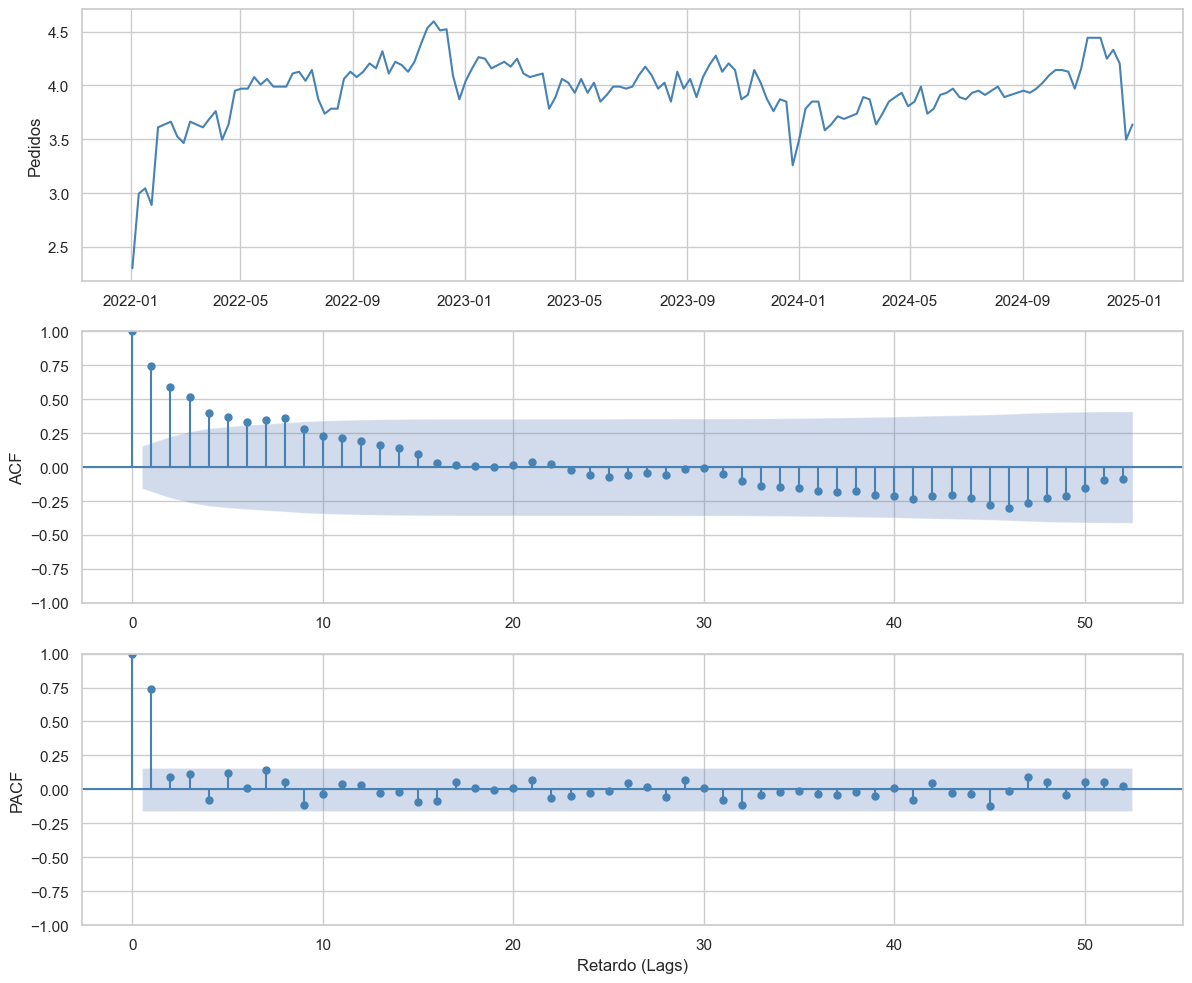

In [56]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Seguimos vendo problemas de tendencia. Diferenciemos a serie transformada.

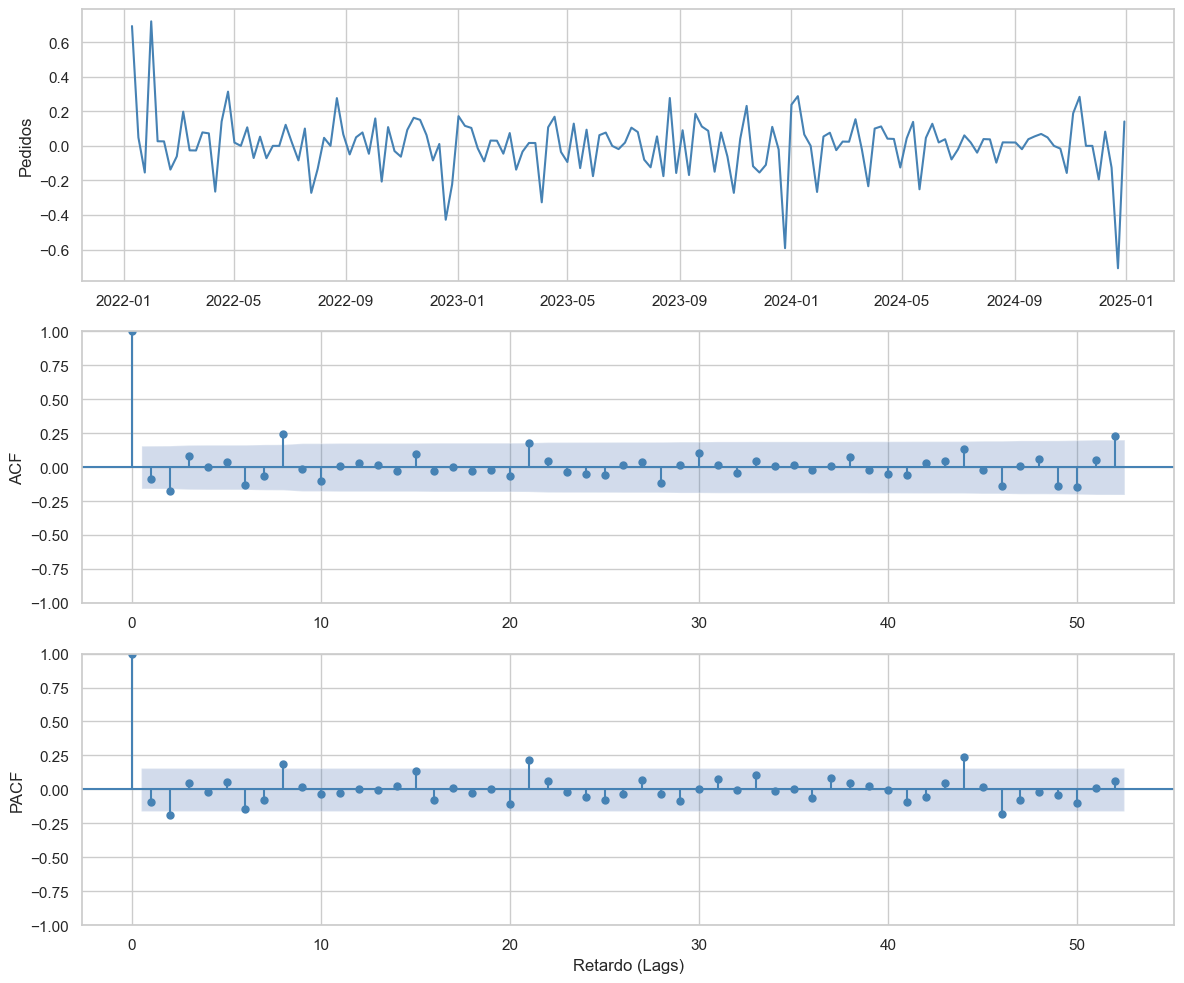

In [57]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Para a serie do log diferenciada podemos suxerir un ARMA(0,0). Co cal a serie tranformada pode vir explicada por un ARIMA(0,1,0).

**Selección automática**

In [58]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=871.007, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-106.677, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-102.857, Time=0.22 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-111.443, Time=0.19 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-106.076, Time=0.41 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-110.164, Time=0.25 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.28 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-108.031, Time=0.39 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-107.290, Time=0.28 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 2.602 seconds
                               SARIMAX Results    

O mellor modelo segundo o AIC sería un ARIMA(1,0,2). Novamente sucede que a función auto_arima non avalía modelos con d=1. Probemos manuealmente o ARIMA(0,1,0) e comparemos o AIC co suposto óptimo.

In [59]:
modelo = 'Cluster 2'

manual_order = (0, 1, 2)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

best_order = manual_order

print(f"Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

Modelo ARIMA (0, 1, 2) axustado correctamente.
AIC = -118.63561565544572


Novamente o AIC mellora ao considerar dito modelo, co cal repetiremos o proceso automático obrgando a que tome d=1:

In [60]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-111.135, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-110.987, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-112.282, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-112.711, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-113.735, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-116.123, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-118.122, Time=0.12 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-116.123, Time=0.14 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-114.122, Time=0.11 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-119.331, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-112.520, Time=0.06 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-117.343, Time=0.25 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-117.345, Time=0.18 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-

Daquela o mellor modelo sería un ARIMA(2,1,0) con AIC = -119.33. Como o modelo suxerido graficamente (ARIMA(0,1,0)) empeora en máis de dúas unidades o AIC óptimo, quedamos co modelo proposto polo criterio automático.

In [61]:
best_order = modelo_global.order

**Detección de atípicos**

In [62]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    
    max_iter=10,    
    burn_in=3      
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2022-01-31 | t-stat: 4.71 > 3.59
   [Iter 2] Detectado: 2024-12-23 | t-stat: 4.49 > 3.59
   [Iter 3] Detectado: 2023-12-25 | t-stat: 4.09 > 3.59
   [Iter 4] Non se atoparon máis atípicos significativos (Max t: 3.23). Fin.
       fecha    t_stat  iter      tipo
0 2022-01-31  4.710930     1  Positivo
1 2024-12-23 -4.489493     2  Negativo
2 2023-12-25 -4.094729     3  Negativo
            bf_pre  bf_peak  bf_post  outlier_20220131  outlier_20241223  \
semana                                                                     
2022-01-03       0        0        0                 0                 0   
2022-01-10       0        0        0                 0                 0   
2022-01-17       0        0        0                 0                 0   
2022-01-24       0        0        0                 0                 0   
2022-01-31       0        0        0                 1                 0   

            outli

Detectamos daquela 3 atípicos: na semana 31-01-2022, na semana 23-12-2024 e na semana 25-12-2023. Axustámolos no modelo mediante variables dummys.

**Estimación ou axuste do modelo**

In [63]:
modelo = 'Cluster 2'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       
    order = datos_arima[modelo]['order'],        
    trend ='n',               
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

# Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.595
Date:                Thu, 22 Jan 2026   AIC                           -171.190
Time:                        19:09:54   BIC                           -143.857
Sample:                    01-03-2022   HQIC                          -160.088
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1233      0.083      1.486      0.137      -0.039       0.286
bf_peak              0.1592      0.085      

Vemos como o coeficiente $\varphi_1$ non é significativo. Debemos fixalo a 0 reaxustar o modelo:

In [64]:
modelo = 'Cluster 2'
print(f"Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],      
    order = datos_arima[modelo]['order'],         
    trend ='n',                
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# Adestramos
modelo_final = model_axuste.fit_constrained(constraints)

print(modelo_final.summary())

Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.416
Date:                Thu, 22 Jan 2026   AIC                           -172.831
Time:                        19:10:19   BIC                           -148.535
Sample:                    01-03-2022   HQIC                          -162.962
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1220      0.090      1.358      0.174      -0.054       0.298
bf_peak              0.1536      0.086      1

Vemos agora que o efecto posterior do B-F non é significativo. Quítamolo do noso modelo e reaxustamos:

In [65]:
modelo = 'Cluster 2'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_post'...")


variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_post'...
Variable 'bf_post' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 5 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  93.564
Date:                Thu, 22 Jan 2026   AIC                           -173.127
Time:                        19:10:54   BIC                           -151.868
Sample:                    01-03-2022   HQIC                          -164.492
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0

Sucede o mesmo agora co efecto pre-BF, facemos o propio:

In [66]:
modelo = 'Cluster 2'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
Variable 'bf_pre' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 4 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  92.310
Date:                Thu, 22 Jan 2026   AIC                           -172.621
Time:                        19:11:25   BIC                           -154.399
Sample:                    01-03-2022   HQIC                          -165.219
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak              0.0

E agora co impacto do propio BF (parece que o modelo o capta directamente)...

In [67]:
modelo = 'Cluster 2'
print("Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")


variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado



print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
 Variable 'bf_peak' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.863
Date:                Thu, 22 Jan 2026   AIC                           -173.726
Time:                        19:11:56   BIC                           -158.541
Sample:                    01-03-2022   HQIC                          -167.558
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131     0

Todos os termos significativos. Quedamos con este modelo.

**Diagnose ou validación do modelo**

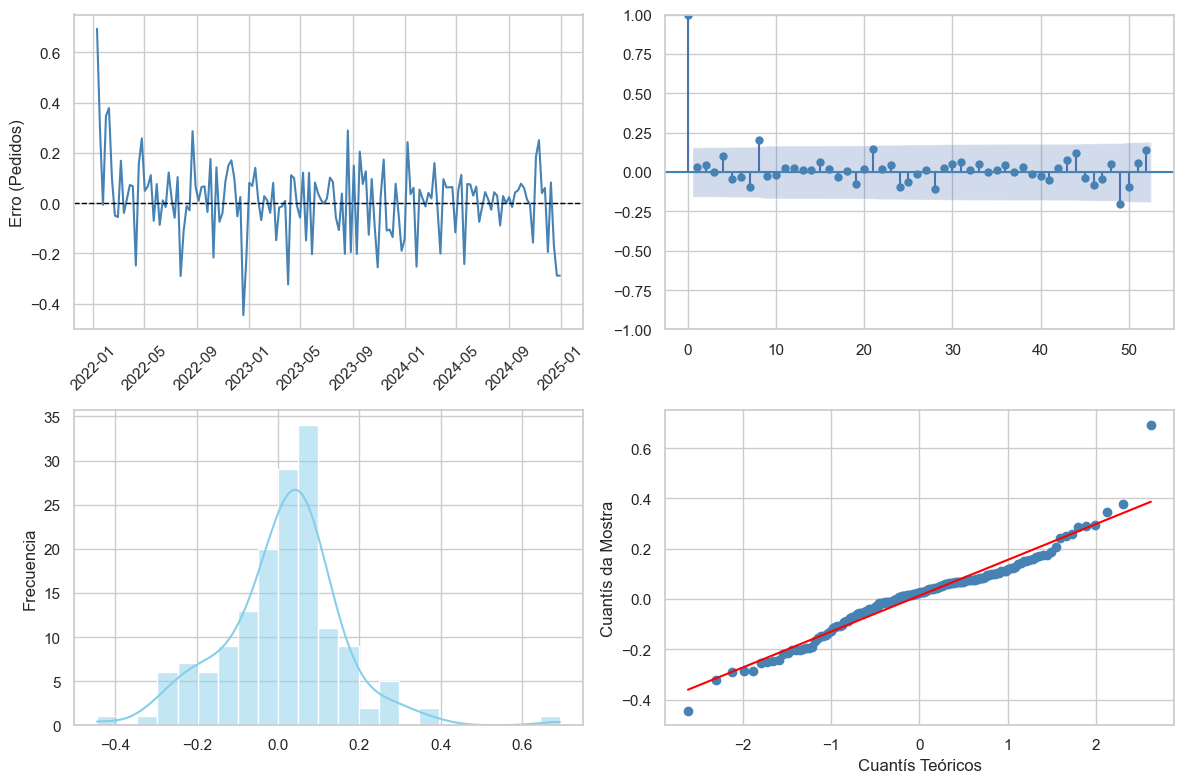


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.2760
  Normalidade (Shapiro): p-value = 0.0000
------------------------------------------------------------


In [69]:
ft.analizar_residuos_arima(modelo_final,lags=52)

O problema co primeiro residuo e pola propia construción do modelo (diferenciado) que non detecta dito dato como atípico polo algoritmo interno (non hai que preocuparse).

In [70]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.863
Date:                Thu, 22 Jan 2026   AIC                           -173.726
Time:                        19:12:11   BIC                           -158.541
Sample:                    01-03-2022   HQIC                          -167.558
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131     0.3842      0.036     10.650      0.000       0.314       0.455
outlier_20241223    -0.4025      0.045     -9.016      0.000      -0.490      -0.315
outlier_20231225    -0.3793      0.073     -5.215      0.000      -0.522      -0.237
ar.L1 (fixed)             0        nan        nan        nan         nan         nan
ar.L2               -0.2129      0.093     -2.277      0.023      -0.396      -0.030
sigma2               0.0178      0.002     10.148      0.000       0.014       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 7.81
Prob(Q):                              0.70   Prob(JB):                         0.02
Heteroskedasticity (H):               0.57   Skew:                            -0.40
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Agora vemos que non se rexeita a hipótese de incorrelación (p-valor = 0.70), nin a de homocedasticidade (p-valor = 0.05), nin tampouco a de media 0 (p-valor = 0.27). En cambio si se rexeita a hipótese de normalidade (JB: p-valor = 0.02 e SW: p-valor ~= 0). Polo tanto o modelo así axustado si é válido e podemos pasar á predición.

#### Predicións

Moi impostante sinalar que, como axustamos o modelo á serie transformada (log), debemos facer as predicións con estos datos e, para poder interpretar e avaliar as métricas, transformar as predicións mediante a función inversa (exp):

--- VALIDACIÓN ROLLING WINDOW: Cluster 2 ---
   Variables en modelo: 3
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (2, 1, 0)
 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=3.95
   > Semana 20/38: Pred=3.90
   > Semana 30/38: Pred=3.73


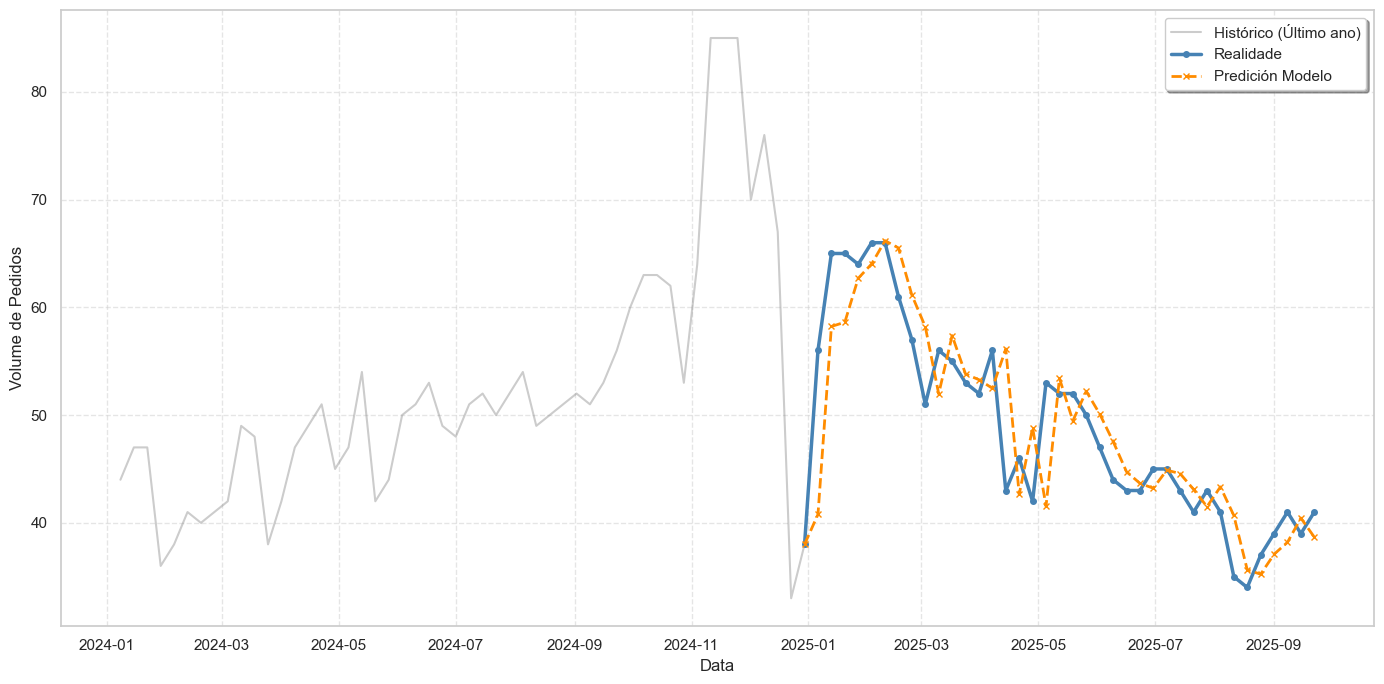

In [71]:
modelo = 'Cluster 2'
print(f"--- VALIDACIÓN ROLLING WINDOW: {modelo} ---")

datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True           
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [72]:
modelo = 'Cluster 2'
# CÁLCULO DE MÉTRICAS
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- AVALIACIÓN: Cluster 2 (Rolling) ---
MAE:  3.60
RMSE: 4.94
MAPE: 7.38%
MASE: 0.63 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos daquela que o MAPE é do 7.38% e o MASE de 0.63, co cal obtemos uns bos resultados.

Gardamos a información da análise de intervención e atípicos para empregar nos modelos Prophet:

In [73]:
modelo = 'Cluster 2'

if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- GARDADO FINAL PARA PROPHET: {modelo} ---")

df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

export_para_prophet[modelo] = df_prophet

print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- GARDADO FINAL PARA PROPHET: Cluster 2 ---
    Empaquetando datos de Cluster 2 para Prophet...

 Datos exportados para Cluster 2.
   Dimensións: (195, 5)
   Columnas incluídas: ['semana', 'n_pedidos', 'outlier_20220131', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  outlier_20220131  outlier_20241223  \
190 2025-08-25       37.0                 0                 0   
191 2025-09-01       39.0                 0                 0   
192 2025-09-08       41.0                 0                 0   
193 2025-09-15       39.0                 0                 0   
194 2025-09-22       41.0                 0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Cluster 3

Recordemos que o terceiro cluster estaba formado polos clientes de alimentación e industria.

In [74]:
df_cluster_3 = datos['Cluster 3'].set_index('semana')

#### Análise de intervención: efecto do Black Friday

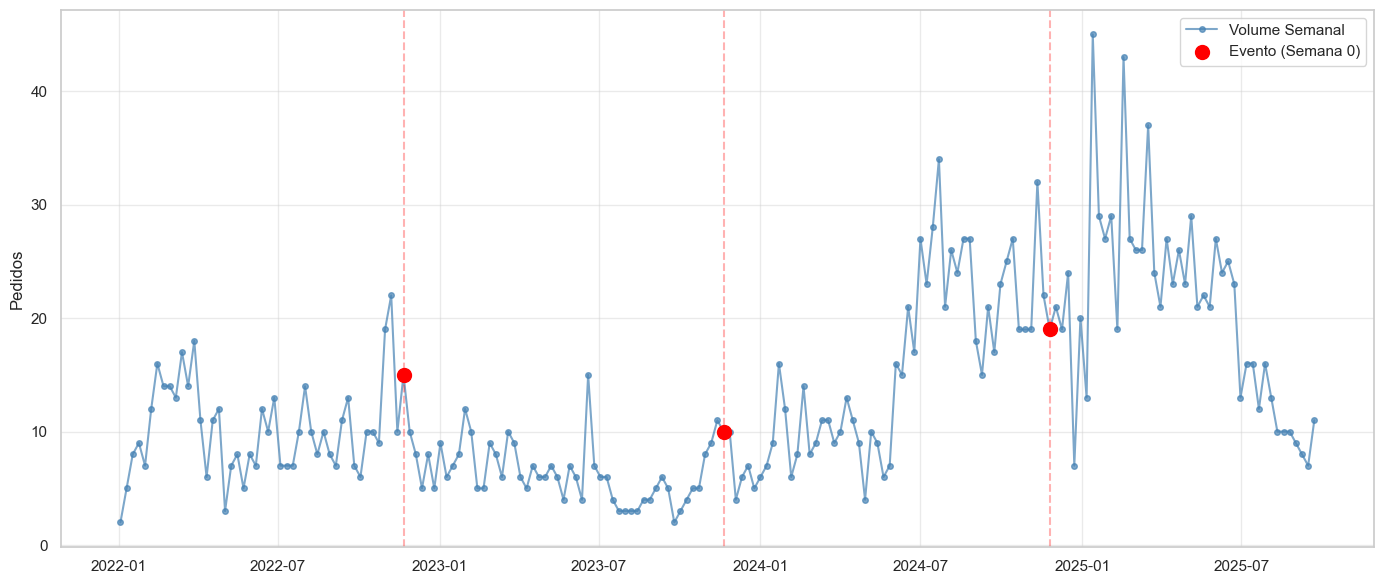

In [75]:
ft.plot_analisis_intervencion(df_input=df_cluster_3,
                              fechas_clave=fechas_bf)

Para os clientes deste cluster non apreciamos visualmente un gran impacto do Black Friday nin previo nin posterior. Porén, podemos modelar dita intervención e ver posterioremente se ten efecto significativo ou non á hora de axustar o modelo. 

In [76]:
modelo = 'Cluster 3'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_3)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap mostrais

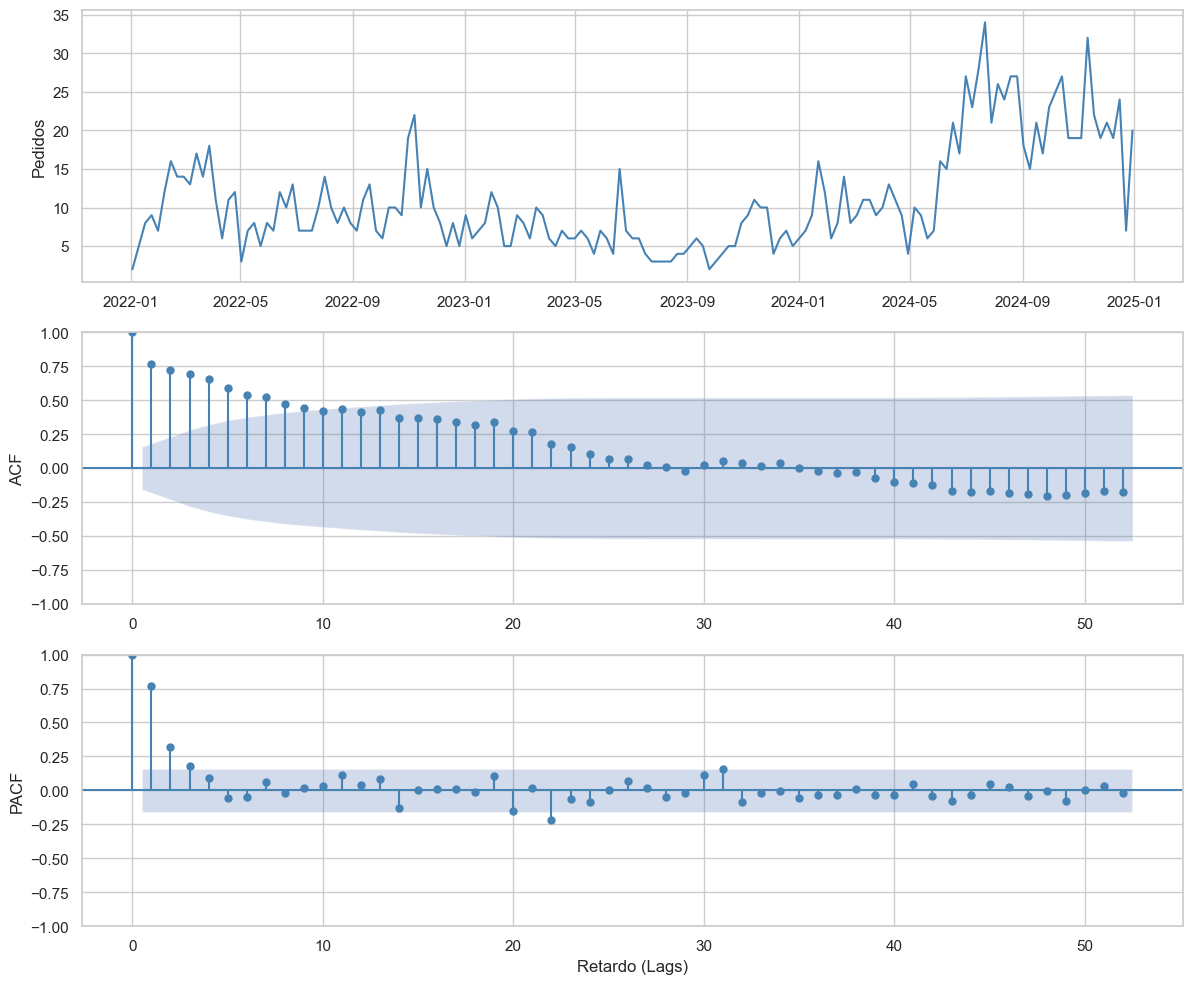

In [77]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

No gráfico secuencial podemos observar un posible problema de heterocedasticidade, ata maio do 2024 a varianza é pequena, mentres que a partir deste momento, ademáis de crecer o nivel medio tamén oscila de forma máis significativa. Polo tanto procederemos a aplicar a transformación log á nosa serie.

In [78]:
modelo = 'Cluster 3'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

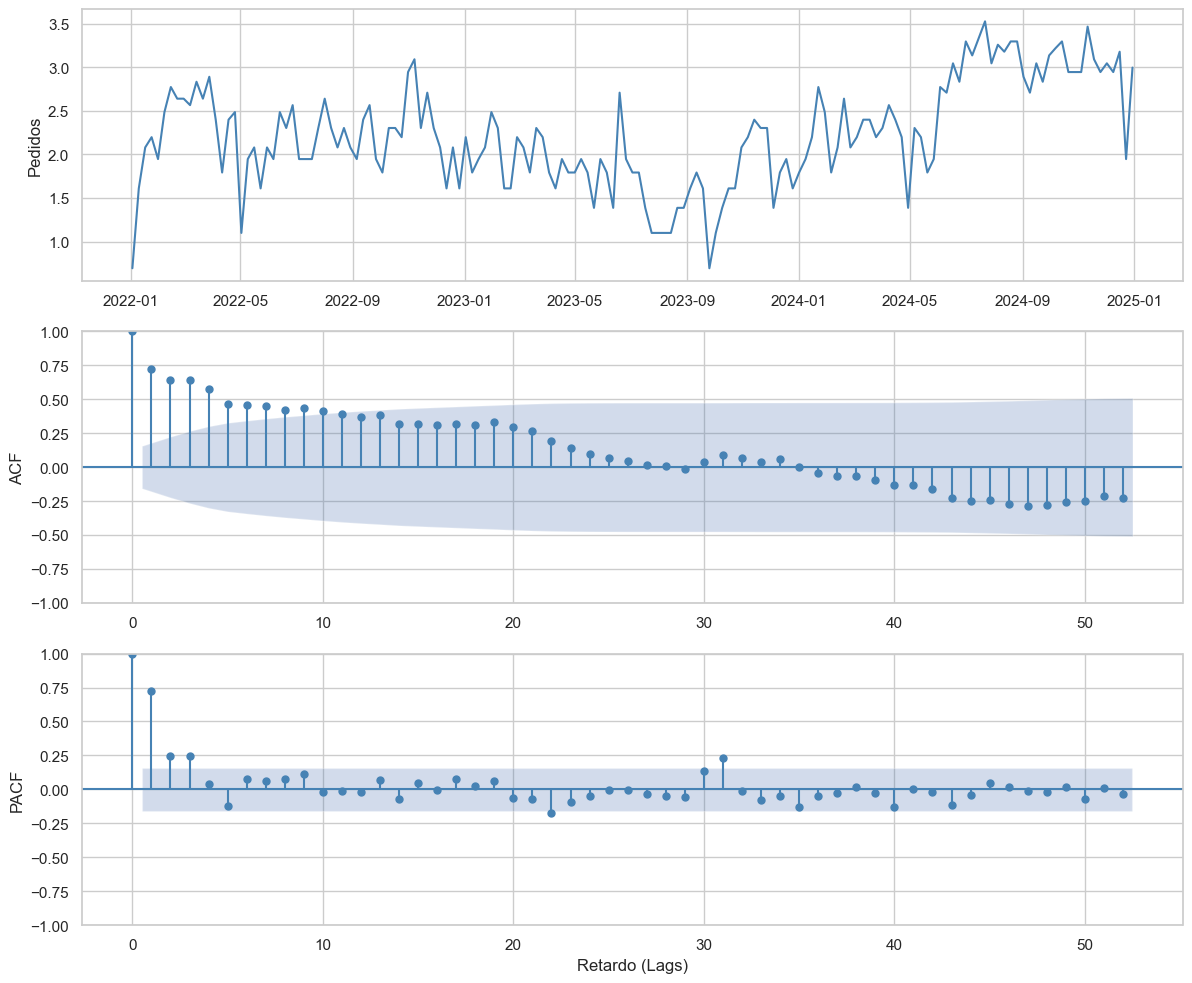

In [79]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Estando o problema de heterocedasticidade corrixido, seguimos vendo tendencia a partir de maio de 2024 fundamentalmente. Daquela diferenciamos a serie.

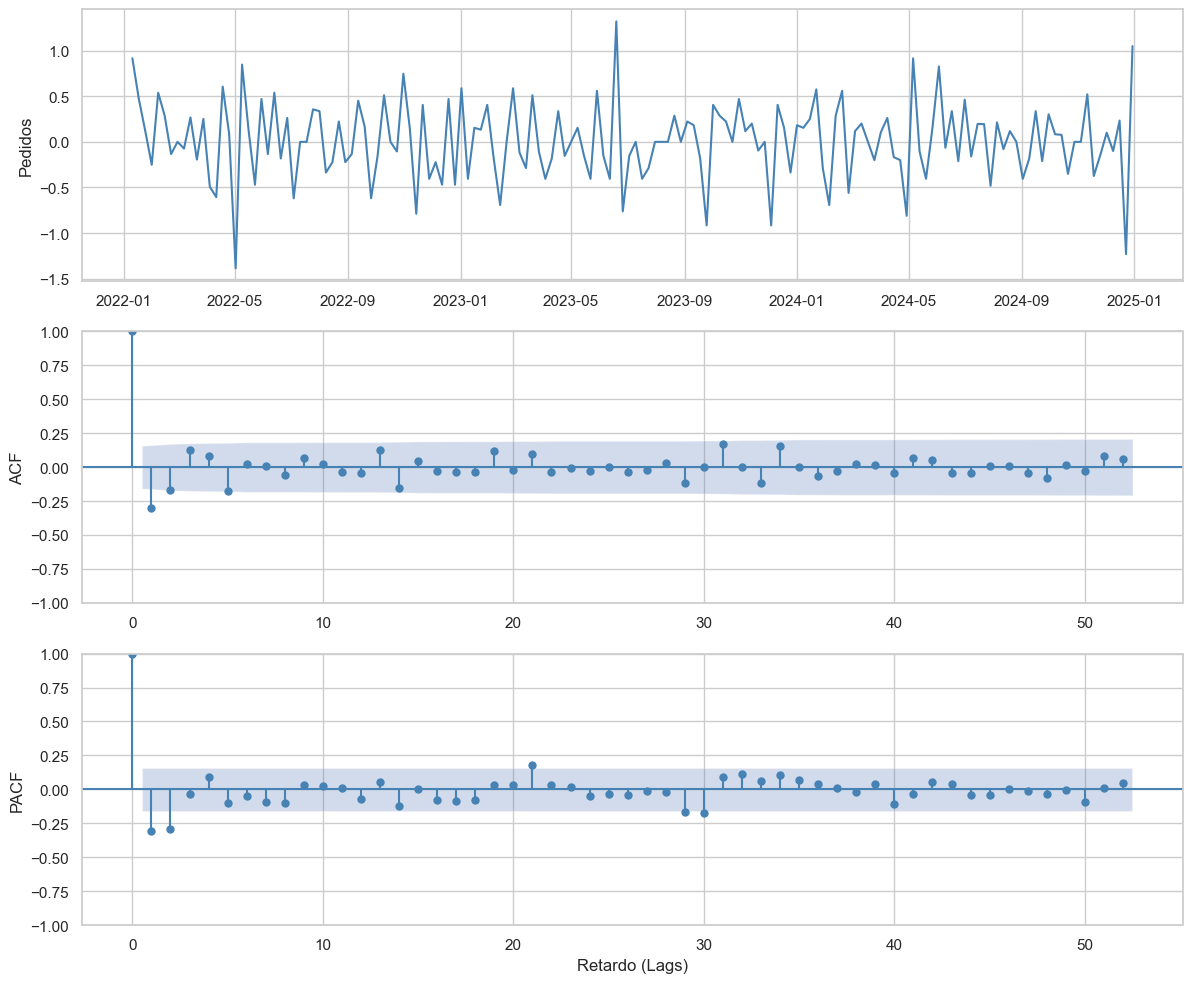

In [80]:
modelo = 'Cluster 3'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Unha vez diferenciada a serie transformada, os problemas de tendencia corríxense.  

Daquela, a serie diferenciada pode vir explicada ou ben por un MA(1) ou ben por un AR(2). Así, un modelo para a serie orixinal (transformada) podería ser ARIMA(0,1,1) ou ARIMA(2,1,0).

#### Selección do modelo mediante AICc

In [81]:
modelo = 'Cluster 3'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=179.126, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=165.801, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=153.816, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=177.322, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=153.911, Time=0.17 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=153.281, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=154.819, Time=0.17 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=154.709, Time=0.17 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=156.629, Time=0.29 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=151.787, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=152.207, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=153.291, Time=0.08 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=153.142, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=152.456, Ti

In [82]:
modelo = 'Cluster 3'

manual_order = (2, 1, 0)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])


best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (2, 1, 0) axustado correctamente.
AIC = 149.92350800883338


#### Detección de atípicos (aditivos e innovativos)

Pasamos agora a facer o contraste de outliers e engadir dita información ao noso modelo:

In [84]:
modelo = 'Cluster 3'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    
    max_iter=10,    
    burn_in=3      
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Non se atoparon máis atípicos significativos (Max t: 3.12). Fin.
    Non se atoparon outliers.
Empty DataFrame
Columns: [fecha, t_stat, iter, tipo]
Index: []
            bf_pre  bf_peak  bf_post
semana                              
2022-01-03       0        0        0
2022-01-10       0        0        0
2022-01-17       0        0        0
2022-01-24       0        0        0
2022-01-31       0        0        0


Non se atoparon atípicos, co cal pasamos a axustar o modelo.

#### Estimación ou axuste do modelo

In [85]:
modelo = 'Cluster 3'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")


model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       
    order = datos_arima[modelo]['order'],         
    trend ='n',                
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

#  Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(2, 1, 0) con 3 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -64.630
Date:                Thu, 22 Jan 2026   AIC                            141.259
Time:                        19:14:51   BIC                            159.481
Sample:                    01-03-2022   HQIC                           148.661
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre         0.1316      0.181      0.728      0.467      -0.223       0.486
bf_peak        0.2496      0.286      0.871      0.384      -0

Vemos como os coeficientes correspondentes ao impacto do Black Friday non son significativos. Comezamos eliminando o menos significativo pre-BF:

In [86]:
modelo = 'Cluster 3'
print("Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")


variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

print(modelo_final.summary())

Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
 Variable 'bf_pre' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 2 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -64.860
Date:                Thu, 22 Jan 2026   AIC                            139.721
Time:                        19:15:15   BIC                            154.905
Sample:                    01-03-2022   HQIC                           145.889
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_peak        0.2038      0.265    

Agora a menos significativa é a variable dummy que capta o efecto do propio BF. Quitámola do modelo:

In [87]:
modelo = 'Cluster 3'
print("Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")


variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

print(modelo_final.summary())

Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
 Variable 'bf_peak' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 1 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -65.442
Date:                Thu, 22 Jan 2026   AIC                            138.884
Time:                        19:15:42   BIC                            151.032
Sample:                    01-03-2022   HQIC                           143.818
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_post        0.1300      0.158  

In [88]:
modelo = 'Cluster 3'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_post'...")


variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    order=datos_arima[modelo]['order'],
    trend='n',                   
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_post'...
 Variable 'bf_post' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 0 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -65.707
Date:                Thu, 22 Jan 2026   AIC                            137.414
Time:                        19:16:06   BIC                            146.525
Sample:                    01-03-2022   HQIC                           141.115
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4293      0.084 

#### Diagnose ou análise dos residuos

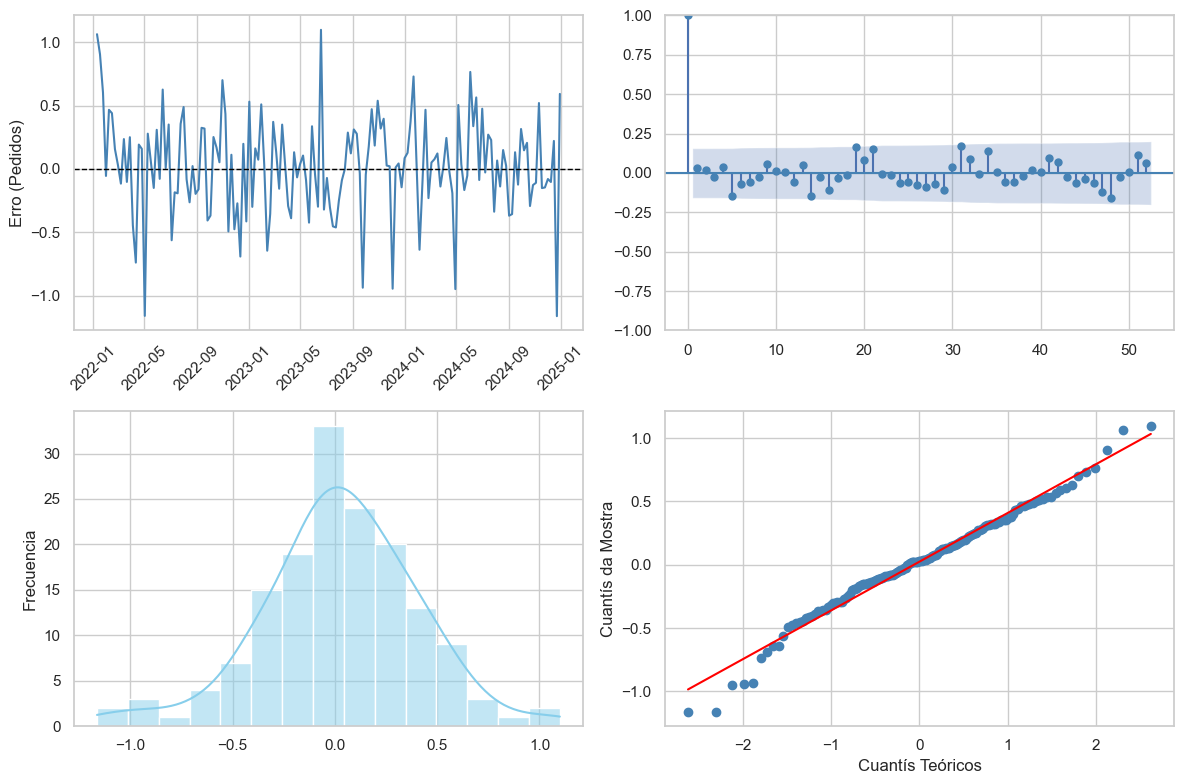


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.4307
  Normalidade (Shapiro): p-value = 0.0458
------------------------------------------------------------


In [89]:
ft.analizar_residuos_arima(modelo_final,lags=52)

Graficamente non observamos problemas de correlación ou heterocedasticidade. En relación á normalidade, os residuos presentan certa asimetría co cal é posible que non se vaia cumprir.

In [90]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -65.707
Date:                Thu, 22 Jan 2026   AIC                            137.414
Time:                        19:16:21   BIC                            146.525
Sample:                    01-03-2022   HQIC                           141.115
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4293      0.084     -5.139      0.000      -0.593      -0.266
ar.L2         -0.3105      0.082     -3.807      0.000      -0.470      -0.151
sigma2         0.1374      0.013     10.404      0.000       0.112       0.163
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):                11.10
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                            -0.46
Prob(H) (two-sided):                  0.72   Kurtosis:                         3.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Predicións

Da mesma forma que no cluster 2, axustamos o modelo para os datos transformados (log), co cal á hora de predecir debemos facer a transformación inversa (exp):

--- VALIDACIÓN ROLLING WINDOW: Cluster 3 ---
   Variables en modelo: 0
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (2, 1, 0)
 Iniciando Rolling Window ARIMAX (38 semanas)...
  Aviso: O modelo non ten variables exóxenas (Arima Puro).
   > Semana 10/38: Pred=3.39


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   > Semana 20/38: Pred=3.14
   > Semana 30/38: Pred=2.62


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


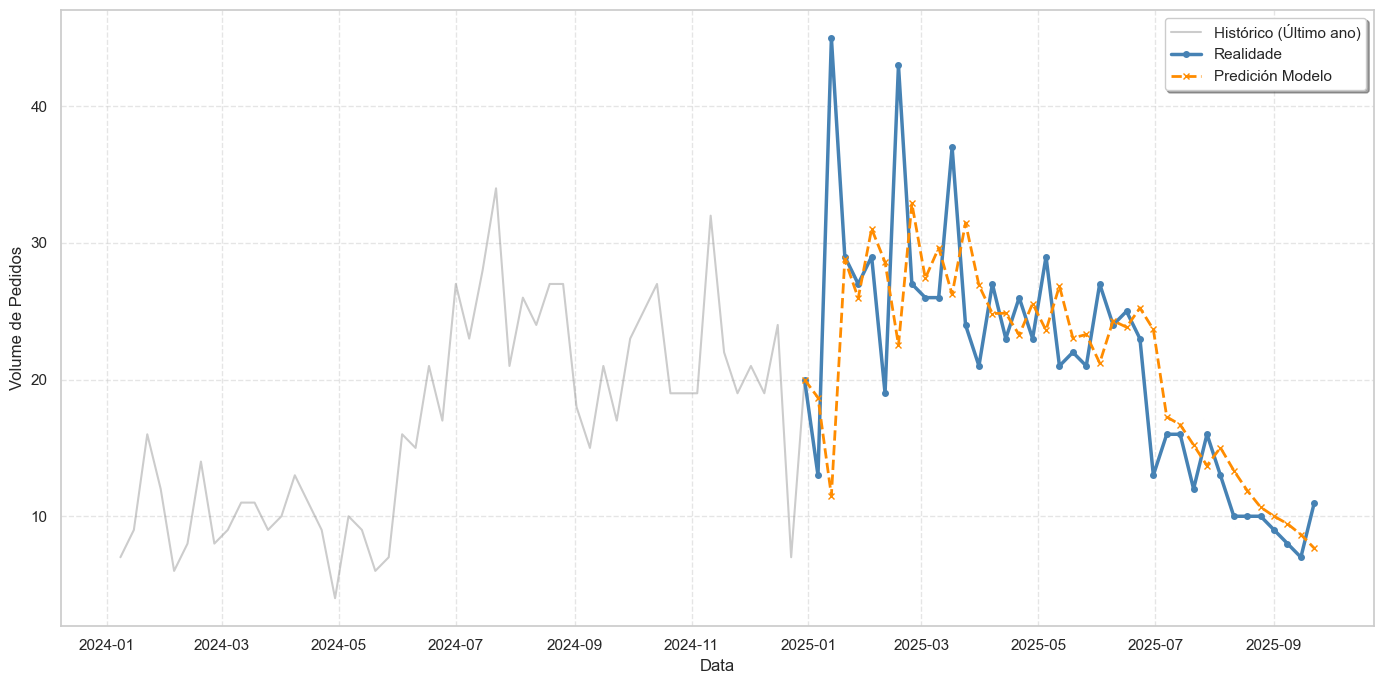

In [91]:
modelo = 'Cluster 3'
print(f"--- VALIDACIÓN ROLLING WINDOW: {modelo} ---")

datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True          
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=preds_rolling,
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [92]:
modelo = 'Cluster 3'
# CÁLCULO DE MÉTRICAS
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)

--- AVALIACIÓN: Cluster 3 (Rolling) ---
MAE:  4.59
RMSE: 7.65
MAPE: 20.73%
MASE: 1.42 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo non supera ao benchmark (MASE > 1).


En particular, podemos calcular as métricas prescindindo do primeiro trimestre do ano (onde se ven comportamentos anómalos), para avaliar así o rendemento do modelo no período de comportamento máis estable do sector.

In [93]:
modelo = 'Cluster 3'

print(f"--- ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: {modelo} ---")

start_date_Q2 = '2025-04-01'

y_true_clean = datos_arima[modelo]['y_test'].loc[start_date_Q2:]
y_pred_clean = datos_arima[modelo]['predicions'].loc[start_date_Q2:]

print(f"   Datos totais 2025: {len(datos_arima[modelo]['y_test'])} semanas")
print(f"   Datos analizados (Abr-Dec): {len(y_true_clean)} semanas")

if len(y_true_clean) > 0:
    metricas_clean = ft.calcular_metricas_completas(
        y_true=y_true_clean,
        y_pred=y_pred_clean,
        y_train=datos_arima[modelo]['y_train'],
        m=1, 
        etiqueta=f"{modelo} (Sen Q1)"
    )
    
    print("\n   --- MELLORA OBTIDA AO ELIMINAR Q1 ---")
    
    for key in ['MAE', 'RMSE', 'MAPE', 'MASE']:
        valor_total = metricas[key]
        valor_clean = metricas_clean[key]
        diff = valor_total - valor_clean
        
        estado = " Mellora" if diff > 0 else " Empeora"
        print(f"   {key}: {valor_total:.2f} -> {valor_clean:.2f} | Dif: {diff:.2f} ({estado})")

else:
    print(" Erro: Non quedan datos despois do corte.")

datos_arima[modelo]['metricas'] = metricas_clean

--- ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: Cluster 3 ---
   Datos totais 2025: 38 semanas
   Datos analizados (Abr-Dec): 25 semanas
--- AVALIACIÓN: Cluster 3 (Sen Q1) ---
MAE:  2.68
RMSE: 3.46
MAPE: 17.21%
MASE: 0.83 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).

   --- MELLORA OBTIDA AO ELIMINAR Q1 ---
   MAE: 4.59 -> 2.68 | Dif: 1.92 ( Mellora)
   RMSE: 7.65 -> 3.46 | Dif: 4.19 ( Mellora)
   MAPE: 20.73 -> 17.21 | Dif: 3.51 ( Mellora)
   MASE: 1.42 -> 0.83 | Dif: 0.59 ( Mellora)


Gardamos a información da análise de intervención e atípicos para o Prophet:

In [94]:
modelo = 'Cluster 3'

if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- GARDADO FINAL PARA PROPHET: {modelo} ---")

df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

export_para_prophet[modelo] = df_prophet

print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- GARDADO FINAL PARA PROPHET: Cluster 3 ---
    Empaquetando datos de Cluster 3 para Prophet...

 Datos exportados para Cluster 3.
   Dimensións: (195, 2)
   Columnas incluídas: ['semana', 'n_pedidos']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos
190 2025-08-25       10.0
191 2025-09-01        9.0
192 2025-09-08        8.0
193 2025-09-15        7.0
194 2025-09-22       11.0


## Modelos Prophet

Probaremos agora cunha aproximación diferente, axustando os modelos Prophet. Estos son uns modelos aditivos de series temporais con compoñentes interpretables:

$y(t) = g(t) + s(t) + h(t) + \epsilon_t$,

onde

$g(t)$ é a tendencia.

$s(t)$ é a estacionalidade.

$h(t)$ é o efecto dos festivos ou eventos especiais.

$\epsilon_t$ o erro.

In [95]:
# LISTA DOS FESTIVOS:
festivos = [
    '2022-04-14', '2022-04-15', '2022-04-18',
    '2022-05-26', '2023-04-06', '2023-04-07', '2023-04-10',
    '2023-05-18', '2024-03-28', '2024-03-29', '2024-04-01',
    '2024-05-20', '2025-04-17', '2025-04-18',
    '2025-04-21', '2025-05-29'
]
df_festivos_prophet = ft.preparar_festivos_prophet(festivos)
# Dicionario para gardar resultados:
resultados_prophet = {}

### Modelo xeral

Da mesma forma que para os modelos ARIMA, comezaremos axustando un modelo xeral ao conxunto completo dos nosos datos e, posteriormente, axustaremos a cada cluster un modelo e compararemos os rendementos das dúas estratexias.

In [96]:
modelo = 'Global'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' 
)
# Gardamos no dicionario
print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Global
    Prophet Prep: Train=157, Test=38
    Regresores detectados (5): ['bf_pre', 'bf_peak', 'bf_post']...
   Variables exóxenas detectadas (5): ['bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']


In [97]:
print(f"\n--- TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario
print(f"  Mellores parámetros: {resultados_prophet[modelo]['params']}")


--- TUNING: Global ---
 Iniciando Grid Search con 64 combinacións...


19:19:40 - cmdstanpy - INFO - Chain [1] start processing
19:19:40 - cmdstanpy - INFO - Chain [1] done processing
19:19:42 - cmdstanpy - INFO - Chain [1] start processing
19:19:42 - cmdstanpy - INFO - Chain [1] start processing
19:19:42 - cmdstanpy - INFO - Chain [1] start processing
19:19:42 - cmdstanpy - INFO - Chain [1] start processing
19:19:42 - cmdstanpy - INFO - Chain [1] start processing
19:19:42 - cmdstanpy - INFO - Chain [1] start processing
19:19:42 - cmdstanpy - INFO - Chain [1] done processing
19:19:42 - cmdstanpy - INFO - Chain [1] done processing
19:19:42 - cmdstanpy - INFO - Chain [1] done processing
19:19:42 - cmdstanpy - INFO - Chain [1] done processing
19:19:42 - cmdstanpy - INFO - Chain [1] done processing
19:19:42 - cmdstanpy - INFO - Chain [1] done processing
19:19:42 - cmdstanpy - INFO - Chain [1] start processing
19:19:42 - cmdstanpy - INFO - Chain [1] done processing
19:19:44 - cmdstanpy - INFO - Chain [1] start processing
19:19:44 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/64: RMSE=20.9564


19:19:52 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing
19:19:52 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing
19:19:52 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing
19:19:52 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing
19:19:54 - cmdstanpy - INFO - Chain [1] start processing
19:19:54 - cmdstanpy - INFO - Chain [1] start processing
19:19:54 - cmdstanpy - INFO - Chain [1] start processing
19:19:54 - cmdstanpy - INFO - Chain [1

   > Combinación 10/64: RMSE=20.4243


...

19:21:50 - cmdstanpy - INFO - Chain [1] done processing
19:21:52 - cmdstanpy - INFO - Chain [1] start processing
19:21:52 - cmdstanpy - INFO - Chain [1] start processing
19:21:52 - cmdstanpy - INFO - Chain [1] done processing
19:21:52 - cmdstanpy - INFO - Chain [1] start processing
19:21:52 - cmdstanpy - INFO - Chain [1] start processing
19:21:52 - cmdstanpy - INFO - Chain [1] start processing
19:21:52 - cmdstanpy - INFO - Chain [1] done processing
19:21:52 - cmdstanpy - INFO - Chain [1] done processing
19:21:52 - cmdstanpy - INFO - Chain [1] start processing
19:21:52 - cmdstanpy - INFO - Chain [1] done processing
19:21:52 - cmdstanpy - INFO - Chain [1] done processing
19:21:53 - cmdstanpy - INFO - Chain [1] done processing
19:21:54 - cmdstanpy - INFO - Chain [1] start processing
19:21:54 - cmdstanpy - INFO - Chain [1] done processing
19:21:56 - cmdstanpy - INFO - Chain [1] start processing
19:21:56 - cmdstanpy - INFO - Chain [1] start processing
19:21:56 - cmdstanpy - INFO - Chain [1]

   > Combinación 60/64: RMSE=20.1084


19:22:08 - cmdstanpy - INFO - Chain [1] start processing
19:22:08 - cmdstanpy - INFO - Chain [1] start processing
19:22:08 - cmdstanpy - INFO - Chain [1] done processing
19:22:08 - cmdstanpy - INFO - Chain [1] start processing
19:22:08 - cmdstanpy - INFO - Chain [1] start processing
19:22:08 - cmdstanpy - INFO - Chain [1] done processing
19:22:08 - cmdstanpy - INFO - Chain [1] start processing
19:22:08 - cmdstanpy - INFO - Chain [1] done processing
19:22:08 - cmdstanpy - INFO - Chain [1] start processing
19:22:08 - cmdstanpy - INFO - Chain [1] done processing
19:22:08 - cmdstanpy - INFO - Chain [1] done processing
19:22:09 - cmdstanpy - INFO - Chain [1] done processing
19:22:09 - cmdstanpy - INFO - Chain [1] start processing
19:22:09 - cmdstanpy - INFO - Chain [1] done processing
19:22:11 - cmdstanpy - INFO - Chain [1] start processing
19:22:11 - cmdstanpy - INFO - Chain [1] start processing
19:22:11 - cmdstanpy - INFO - Chain [1] start processing
19:22:11 - cmdstanpy - INFO - Chain [1


 Grid Search Completado.
   Mellor RMSE: 19.4172
   Parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}
  Mellores parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}


19:22:18 - cmdstanpy - INFO - Chain [1] done processing


In [98]:
print(f"\n--- ROLLING WINDOW: {modelo} ---")

# Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'],  
    verbose=True
)

19:22:32 - cmdstanpy - INFO - Chain [1] start processing
19:22:32 - cmdstanpy - INFO - Chain [1] done processing
19:22:32 - cmdstanpy - INFO - Chain [1] start processing
19:22:32 - cmdstanpy - INFO - Chain [1] done processing



--- ROLLING WINDOW: Global ---
 Iniciando Prophet Rolling Window (38 pasos)...


19:22:32 - cmdstanpy - INFO - Chain [1] start processing
19:22:32 - cmdstanpy - INFO - Chain [1] done processing
19:22:32 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=117.12


19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:33 - cmdstanpy - INFO - Chain [1] start processing
19:22:33 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1]

   > Semana 20/38: Pred=117.06


19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1]

   > Semana 30/38: Pred=93.26


19:22:34 - cmdstanpy - INFO - Chain [1] start processing
19:22:34 - cmdstanpy - INFO - Chain [1] done processing
19:22:35 - cmdstanpy - INFO - Chain [1] start processing
19:22:35 - cmdstanpy - INFO - Chain [1] done processing
19:22:35 - cmdstanpy - INFO - Chain [1] start processing
19:22:35 - cmdstanpy - INFO - Chain [1] done processing
19:22:35 - cmdstanpy - INFO - Chain [1] start processing
19:22:35 - cmdstanpy - INFO - Chain [1] done processing
19:22:35 - cmdstanpy - INFO - Chain [1] start processing
19:22:35 - cmdstanpy - INFO - Chain [1] done processing



--- ANÁLISE GRÁFICA: Global ---


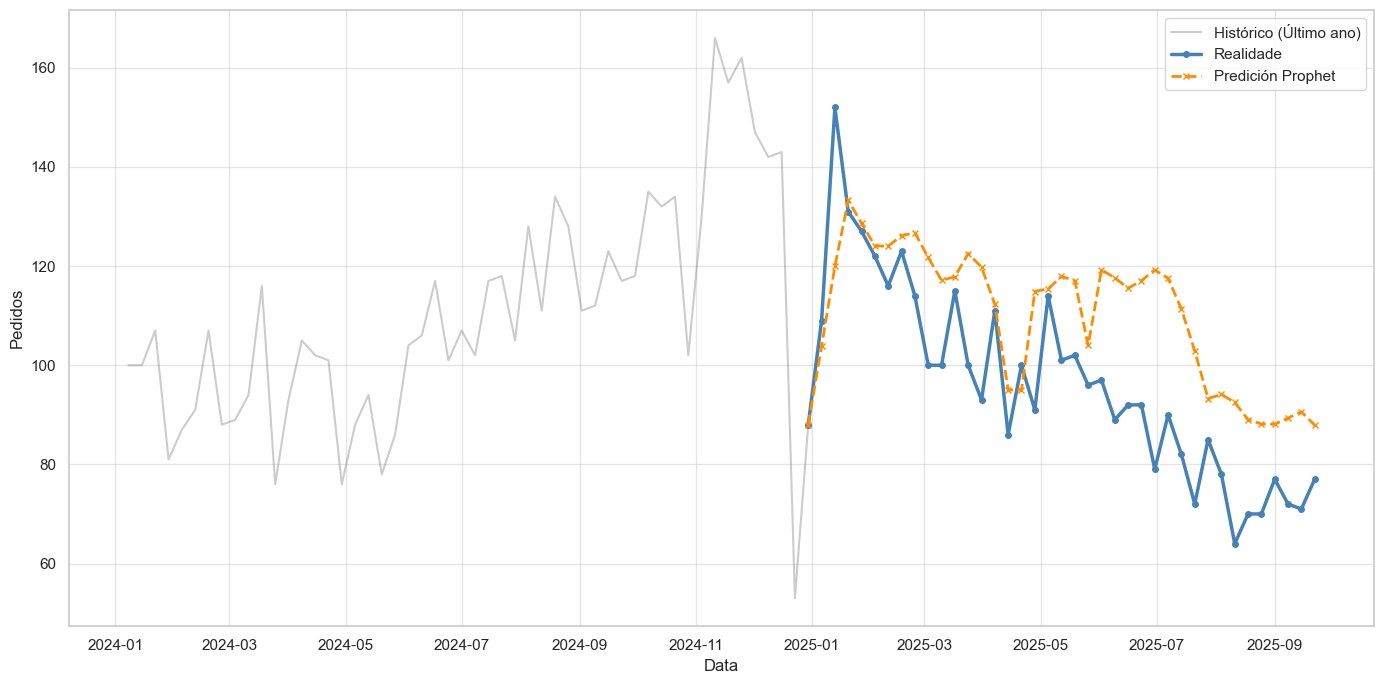

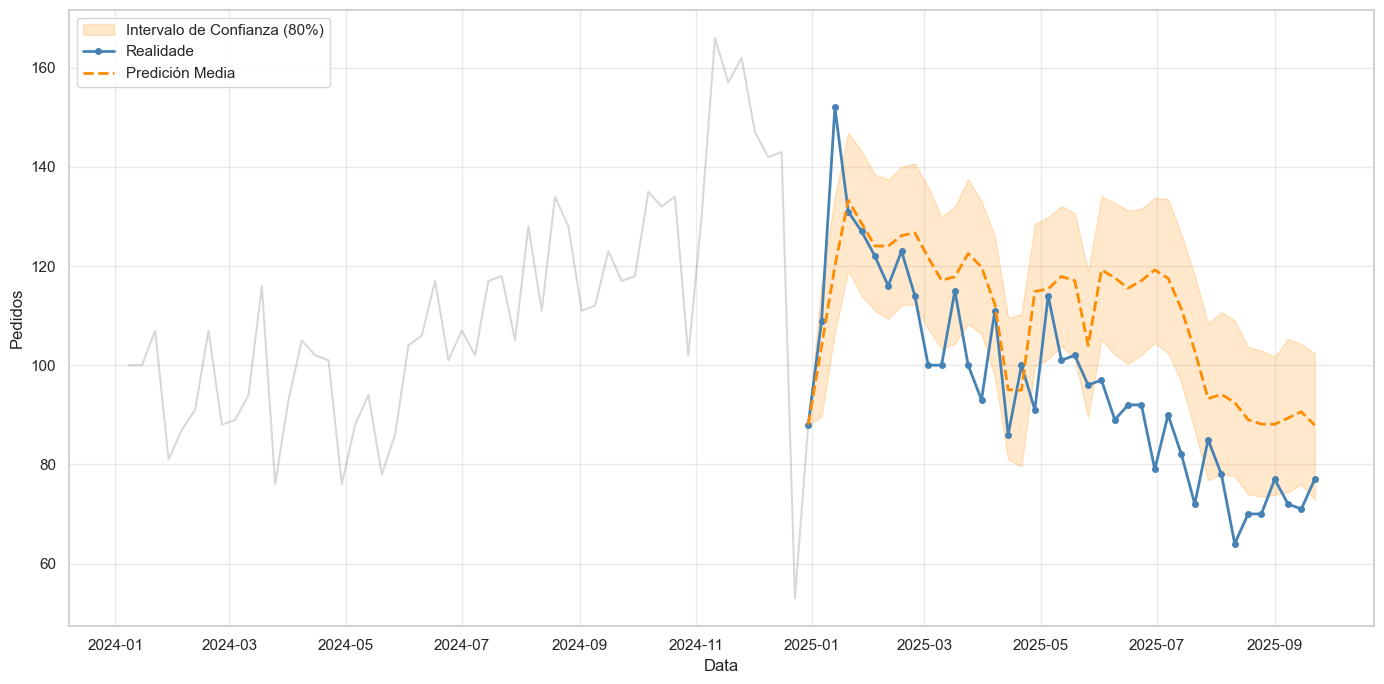

In [99]:
print(f"\n--- ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade 
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza 
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

E avaliamos o rendemento do modelo:

Neste caso, como temos estacionalidade anual, debemos modificar a función que calcula o MASE posto que agora temos que comparar coa predición naïve do valor $x_t$ co valor observado $s=52$ instantes previos $x_{t-52}$, polo tanto debemos cambiar o denominador de dita medida do erro:

In [100]:
# Cálculo de Métricas
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Global ---
MAE:  16.19
RMSE: 19.19
MAPE: 18.53%
MASE: 0.72 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


19:23:12 - cmdstanpy - INFO - Chain [1] start processing
19:23:12 - cmdstanpy - INFO - Chain [1] done processing


    Xerando compoñentes...


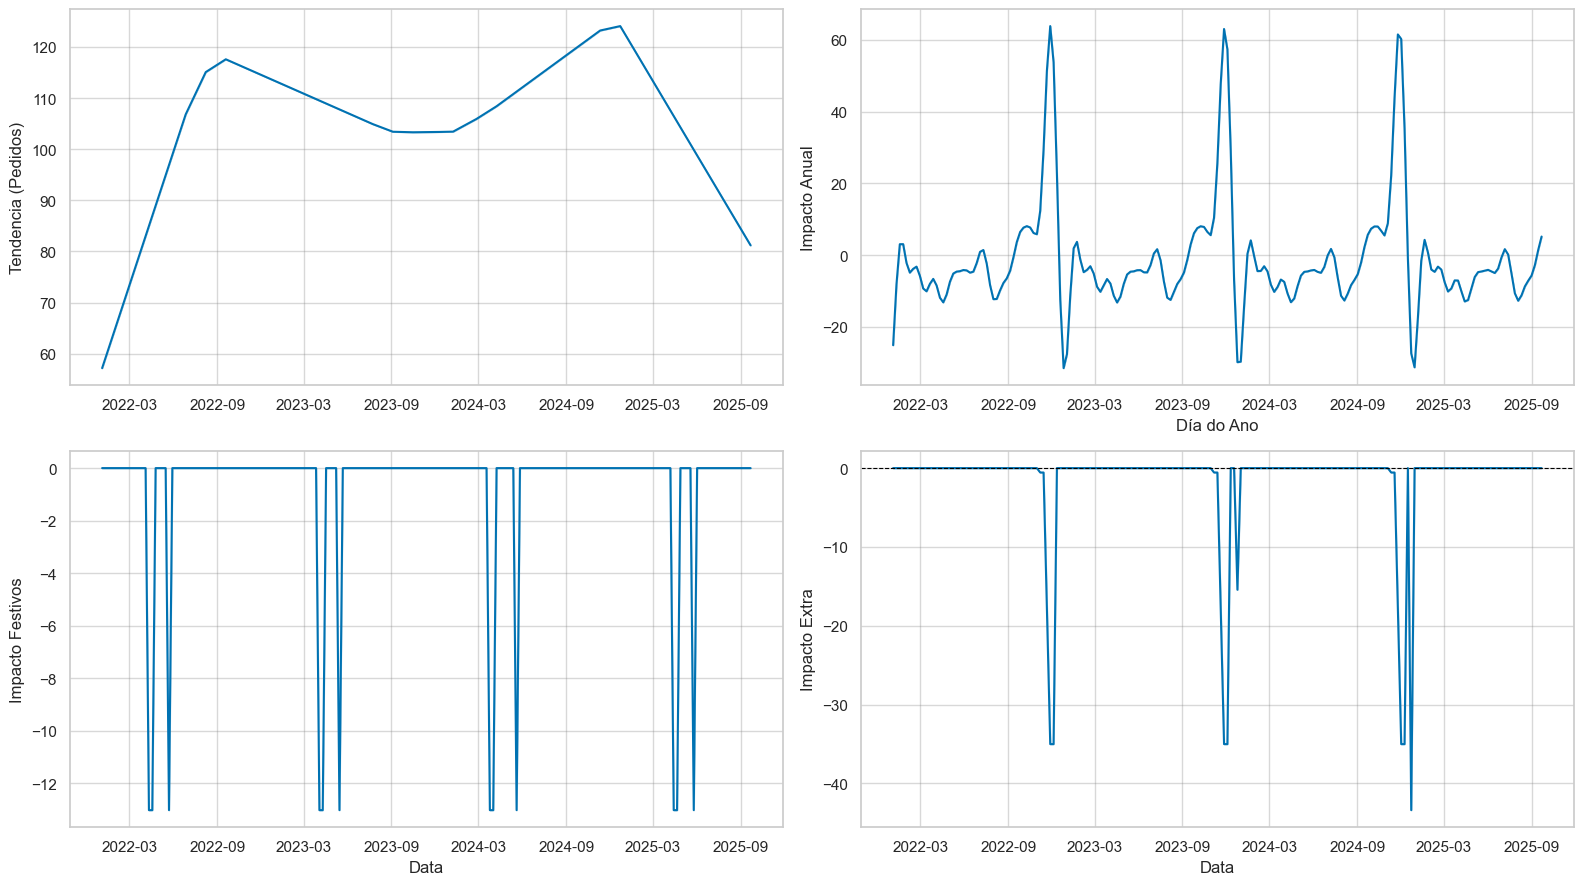

In [101]:
# Compoñentes 
print("    Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), 
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=""
)

Da mesma forma que fixemos para os modelos ARIMA, podemos pensar agora en axustar un modelo para cada cluster de clientes e ver se desta forma construímos un modelo mellor.

### Cluster 1:

Debemos repetir o proceso anterior para os datos do cluster 1, que recordemos que representaba aos clientes de transporte, retail e electrónica.

In [102]:
modelo = 'Cluster 1'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' 
)
# Gardamos no dicionario
print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 1
    Prophet Prep: Train=157, Test=38
    Regresores detectados (2): ['bf_peak', 'bf_post']...
   Variables exóxenas detectadas (2): ['bf_peak', 'bf_post']


In [103]:
print(f"\n--- TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario
print(f"   Mellores parámetros: {resultados_prophet[modelo]['params']}")

19:23:34 - cmdstanpy - INFO - Chain [1] start processing
19:23:34 - cmdstanpy - INFO - Chain [1] done processing



--- TUNING: Cluster 1 ---
 Iniciando Grid Search con 64 combinacións...


19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:36 - cmdstanpy - INFO - Chain [1] done processing
19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:36 - cmdstanpy - INFO - Chain [1] done processing
19:23:36 - cmdstanpy - INFO - Chain [1] done processing
19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:36 - cmdstanpy - INFO - Chain [1] done processing
19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:36 - cmdstanpy - INFO - Chain [1] done processing
19:23:36 - cmdstanpy - INFO - Chain [1] done processing
19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:36 - cmdstanpy - INFO - Chain [1] done processing
19:23:38 - cmdstanpy - INFO - Chain [1] start processing
19:23:38 - cmdstanpy - INFO - Chain [1] start processing
19:23:38 - cmdstanpy - INFO - Chain [1] done processing
19:23:38 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/64: RMSE=18.3319


19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1] done processing
19:23:47 - cmdstanpy - INFO - Chain [1] done processing
19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1] done processing
19:23:47 - cmdstanpy - INFO - Chain [1] done processing
19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1] done processing
19:23:47 - cmdstanpy - INFO - Chain [1] done processing
19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1] done processing
19:23:49 - cmdstanpy - INFO - Chain [1] start processing
19:23:49 - cmdstanpy - INFO - Chain [1] start processing
19:23:49 - cmdstanpy - INFO - Chain [1] done processing
19:23:49 - cmdstanpy - INFO - Chain [1]

...

19:25:43 - cmdstanpy - INFO - Chain [1] start processing
19:25:43 - cmdstanpy - INFO - Chain [1] start processing
19:25:43 - cmdstanpy - INFO - Chain [1] start processing
19:25:43 - cmdstanpy - INFO - Chain [1] start processing
19:25:43 - cmdstanpy - INFO - Chain [1] start processing
19:25:43 - cmdstanpy - INFO - Chain [1] done processing
19:25:43 - cmdstanpy - INFO - Chain [1] done processing
19:25:43 - cmdstanpy - INFO - Chain [1] done processing
19:25:43 - cmdstanpy - INFO - Chain [1] start processing
19:25:43 - cmdstanpy - INFO - Chain [1] done processing
19:25:43 - cmdstanpy - INFO - Chain [1] done processing
19:25:43 - cmdstanpy - INFO - Chain [1] done processing
19:25:43 - cmdstanpy - INFO - Chain [1] start processing
19:25:43 - cmdstanpy - INFO - Chain [1] done processing
19:25:45 - cmdstanpy - INFO - Chain [1] start processing
19:25:45 - cmdstanpy - INFO - Chain [1] start processing
19:25:45 - cmdstanpy - INFO - Chain [1] start processing
19:25:45 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=15.1280


19:25:57 - cmdstanpy - INFO - Chain [1] start processing
19:25:57 - cmdstanpy - INFO - Chain [1] start processing
19:25:57 - cmdstanpy - INFO - Chain [1] start processing
19:25:57 - cmdstanpy - INFO - Chain [1] start processing
19:25:57 - cmdstanpy - INFO - Chain [1] done processing
19:25:57 - cmdstanpy - INFO - Chain [1] done processing
19:25:57 - cmdstanpy - INFO - Chain [1] start processing
19:25:57 - cmdstanpy - INFO - Chain [1] done processing
19:25:57 - cmdstanpy - INFO - Chain [1] start processing
19:25:57 - cmdstanpy - INFO - Chain [1] done processing
19:25:57 - cmdstanpy - INFO - Chain [1] done processing
19:25:58 - cmdstanpy - INFO - Chain [1] done processing
19:25:58 - cmdstanpy - INFO - Chain [1] start processing
19:25:58 - cmdstanpy - INFO - Chain [1] done processing
19:26:00 - cmdstanpy - INFO - Chain [1] start processing
19:26:00 - cmdstanpy - INFO - Chain [1] start processing
19:26:00 - cmdstanpy - INFO - Chain [1] done processing
19:26:00 - cmdstanpy - INFO - Chain [1]


 Grid Search Completado.
   Mellor RMSE: 13.9096
   Parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}
   Mellores parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}


19:26:06 - cmdstanpy - INFO - Chain [1] done processing


In [104]:
print(f"\n--- ROLLING WINDOW: {modelo} ---")

#  Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], 
    verbose=True
)

19:26:17 - cmdstanpy - INFO - Chain [1] start processing
19:26:17 - cmdstanpy - INFO - Chain [1] done processing
19:26:17 - cmdstanpy - INFO - Chain [1] start processing
19:26:17 - cmdstanpy - INFO - Chain [1] done processing
19:26:17 - cmdstanpy - INFO - Chain [1] start processing
19:26:17 - cmdstanpy - INFO - Chain [1] done processing
19:26:17 - cmdstanpy - INFO - Chain [1] start processing



--- ROLLING WINDOW: Cluster 1 ---
 Iniciando Prophet Rolling Window (38 pasos)...


19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] 

   > Semana 10/38: Pred=38.98


19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1] done processing
19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:18 - cmdstanpy - INFO - Chain [1]

   > Semana 20/38: Pred=36.86


19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing


   > Semana 30/38: Pred=30.05


19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing
19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing
19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing
19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing
19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing



--- ANÁLISE GRÁFICA: Cluster 1 ---


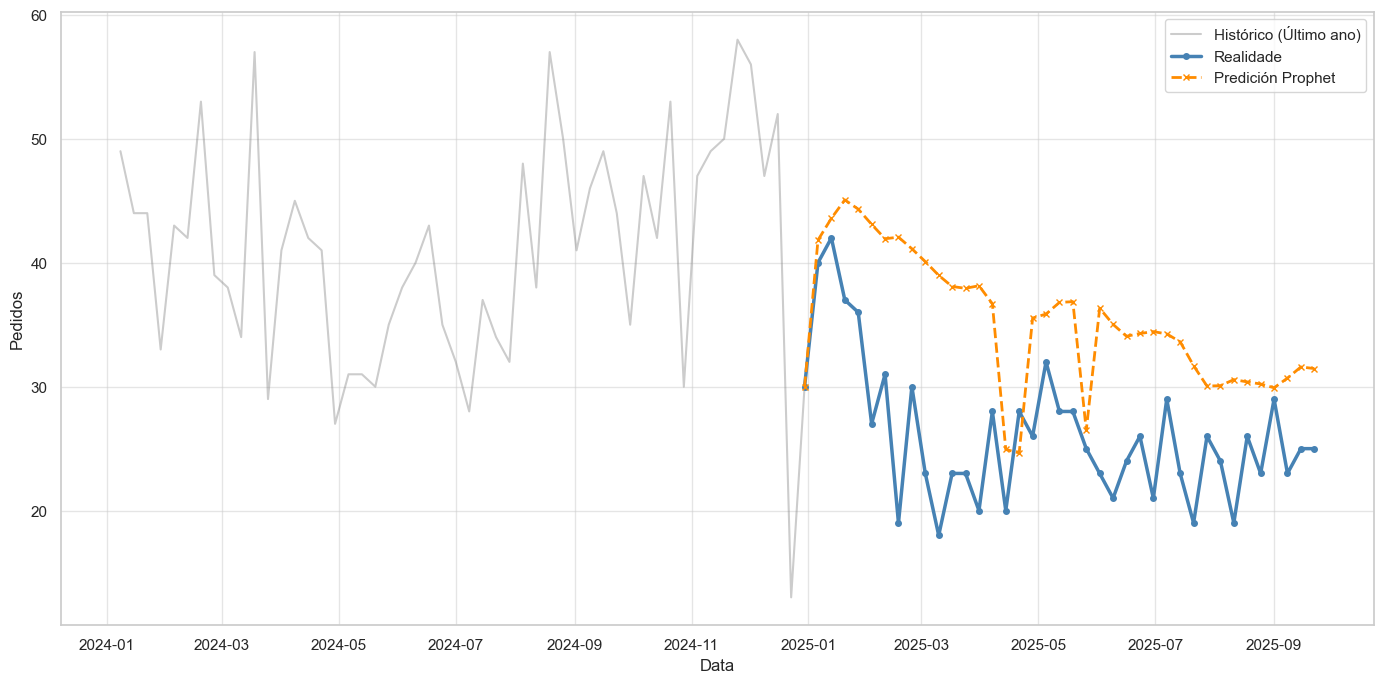

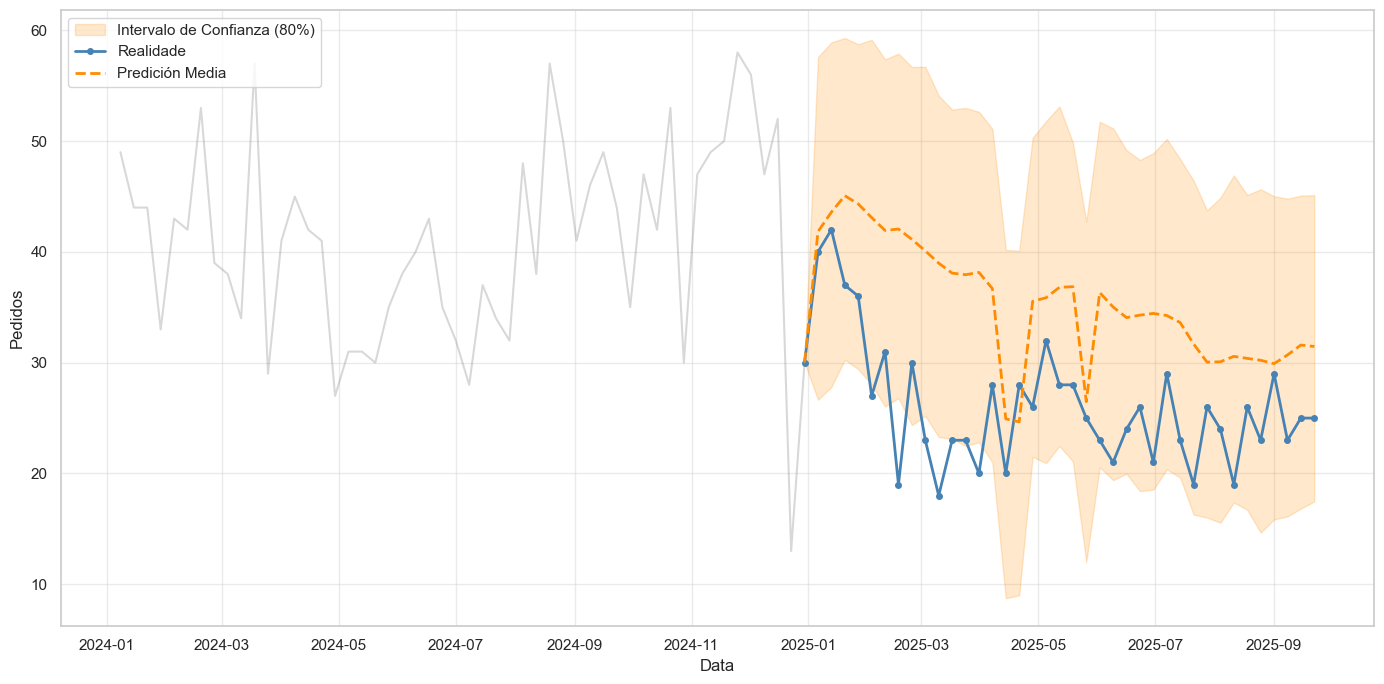

In [105]:
print(f"\n--- ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade 
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza 
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [106]:
# Cálculo de Métricas 
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Cluster 1 ---
MAE:  9.46
RMSE: 10.87
MAPE: 40.44%
MASE: 0.62 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


19:26:51 - cmdstanpy - INFO - Chain [1] start processing
19:26:51 - cmdstanpy - INFO - Chain [1] done processing


   Xerando compoñentes...


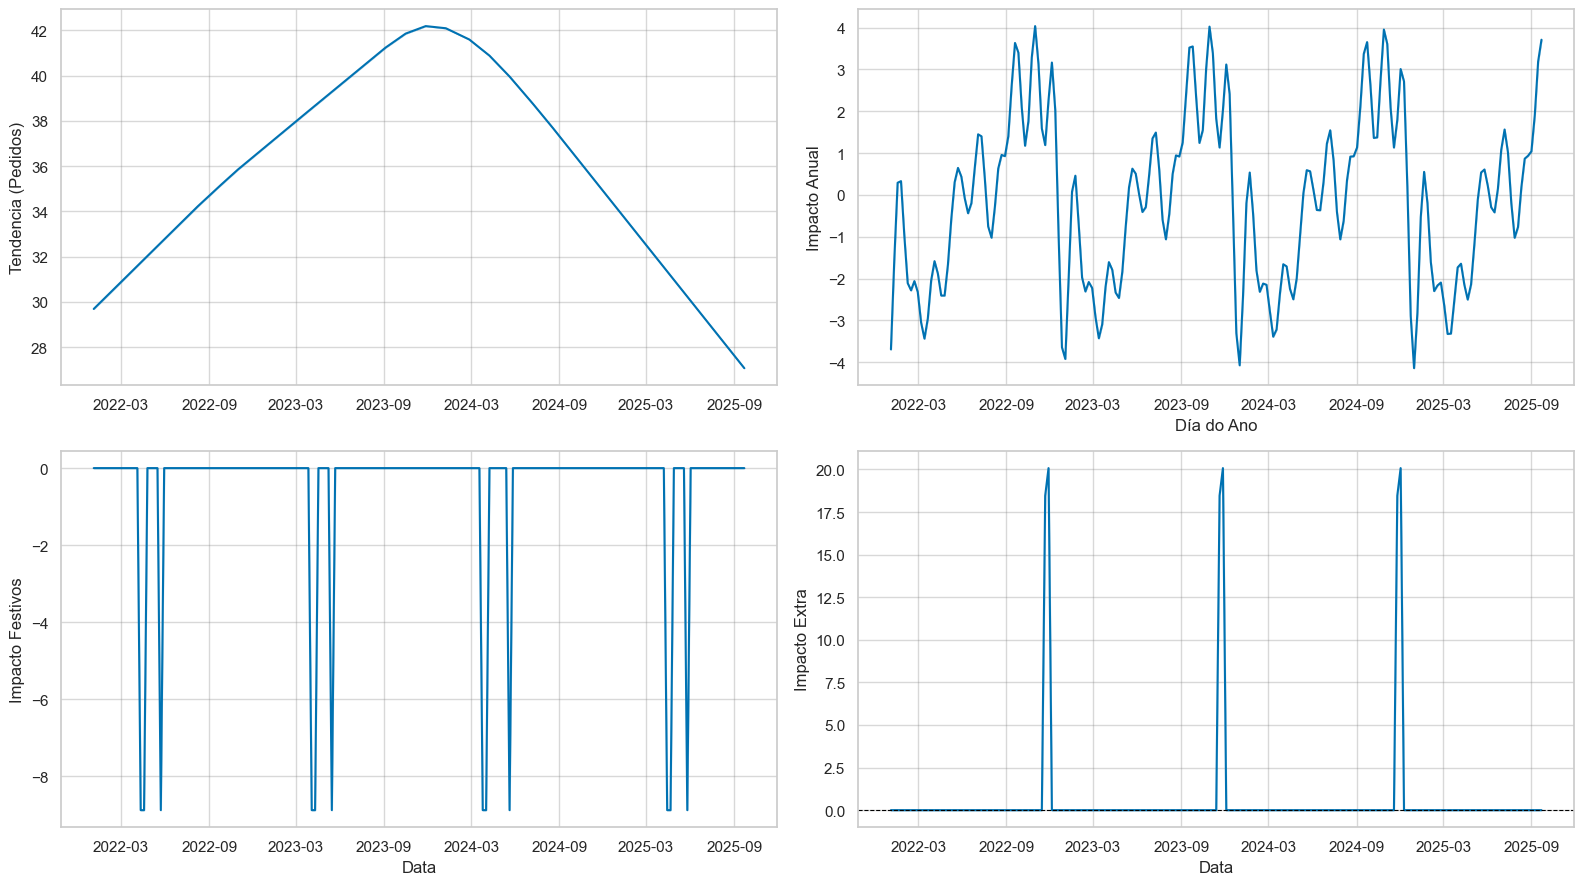

In [107]:
# Compoñentes 
print("   Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]),
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=""
)

Representemos as compoñentes do modelo (o último axutado no Rolling-Window)

### Cluster 2

Facemos o propio para os clientes do cluster 2, que estaba formado polos clientes de paquetería e froita:

In [108]:
modelo = 'Cluster 2'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' 
)
# Gardamos no dicionario
print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 2
    Prophet Prep: Train=157, Test=38
    Regresores detectados (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']...
   Variables exóxenas detectadas (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']


In [109]:
print(f"\n--- TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario
print(f"   Mellores parámetros: {resultados_prophet[modelo]['params']}")

19:27:26 - cmdstanpy - INFO - Chain [1] start processing
19:27:26 - cmdstanpy - INFO - Chain [1] done processing



--- TUNING: Cluster 2 ---
 Iniciando Grid Search con 64 combinacións...


19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - cmdstanpy - INFO - Chain [1] done processing
19:27:28 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - cmdstanpy - INFO - Chain [1] done processing
19:27:28 - cmdstanpy - INFO - Chain [1] done processing
19:27:28 - cmdstanpy - INFO - Chain [1] done processing
19:27:28 - cmdstanpy - INFO - Chain [1] done processing
19:27:28 - cmdstanpy - INFO - Chain [1] done processing
19:27:28 - cmdstanpy - INFO - Chain [1] done processing
19:27:28 - cmdstanpy - INFO - Chain [1] start processing
19:27:28 - 

   > Combinación 5/64: RMSE=13.9270


19:27:41 - cmdstanpy - INFO - Chain [1] start processing
19:27:41 - cmdstanpy - INFO - Chain [1] start processing
19:27:41 - cmdstanpy - INFO - Chain [1] start processing
19:27:41 - cmdstanpy - INFO - Chain [1] start processing
19:27:41 - cmdstanpy - INFO - Chain [1] done processing
19:27:41 - cmdstanpy - INFO - Chain [1] done processing
19:27:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
19:27:41 - cmdstanpy - INFO - Chain [1] start processing
19:27:41 - cmdstanpy - INFO - Chain [1] done processing
19:27:41 - cmdstanpy - INFO - Chain [1] start processing
19:27:41 - cmdstanpy - INFO - Chain [1] start processing
19:27:41 - cmdstanpy - INFO - Chain [1] done processing
19:27:41 - cmdstanpy - INFO - Chain [1] done processing
19:27:42 - cmdstanpy - INFO - Chain [1] done processing
19:27:42 - cmdstanpy - INFO - Chain [1] done processing
19:27:42 - cmdstanpy - INFO - Chain [1] start processing
19:27:42 - 

...

19:30:18 - cmdstanpy - INFO - Chain [1] start processing
19:30:19 - cmdstanpy - INFO - Chain [1] start processing
19:30:19 - cmdstanpy - INFO - Chain [1] start processing
19:30:19 - cmdstanpy - INFO - Chain [1] start processing
19:30:19 - cmdstanpy - INFO - Chain [1] start processing
19:30:19 - cmdstanpy - INFO - Chain [1] done processing
19:30:19 - cmdstanpy - INFO - Chain [1] done processing
19:30:19 - cmdstanpy - INFO - Chain [1] start processing
19:30:19 - cmdstanpy - INFO - Chain [1] done processing
19:30:19 - cmdstanpy - INFO - Chain [1] done processing
19:30:19 - cmdstanpy - INFO - Chain [1] done processing
19:30:19 - cmdstanpy - INFO - Chain [1] done processing
19:30:19 - cmdstanpy - INFO - Chain [1] start processing
19:30:19 - cmdstanpy - INFO - Chain [1] done processing
19:30:21 - cmdstanpy - INFO - Chain [1] start processing
19:30:21 - cmdstanpy - INFO - Chain [1] start processing
19:30:21 - cmdstanpy - INFO - Chain [1] start processing
19:30:21 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=11.2383


19:30:34 - cmdstanpy - INFO - Chain [1] done processing
19:30:35 - cmdstanpy - INFO - Chain [1] start processing
19:30:35 - cmdstanpy - INFO - Chain [1] start processing
19:30:35 - cmdstanpy - INFO - Chain [1] start processing
19:30:35 - cmdstanpy - INFO - Chain [1] start processing
19:30:35 - cmdstanpy - INFO - Chain [1] start processing
19:30:35 - cmdstanpy - INFO - Chain [1] start processing
19:30:36 - cmdstanpy - INFO - Chain [1] done processing
19:30:36 - cmdstanpy - INFO - Chain [1] done processing
19:30:36 - cmdstanpy - INFO - Chain [1] done processing
19:30:36 - cmdstanpy - INFO - Chain [1] done processing
19:30:36 - cmdstanpy - INFO - Chain [1] done processing
19:30:37 - cmdstanpy - INFO - Chain [1] done processing
19:30:37 - cmdstanpy - INFO - Chain [1] start processing
19:30:37 - cmdstanpy - INFO - Chain [1] done processing
19:30:39 - cmdstanpy - INFO - Chain [1] start processing
19:30:39 - cmdstanpy - INFO - Chain [1] start processing
19:30:39 - cmdstanpy - INFO - Chain [1]


 Grid Search Completado.
   Mellor RMSE: 8.6413
   Parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}
   Mellores parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}


19:30:47 - cmdstanpy - INFO - Chain [1] done processing


In [110]:
print(f"\n--- ROLLING WINDOW: {modelo} ---")

# Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], 
    verbose=True
)

19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing



--- ROLLING WINDOW: Cluster 2 ---
 Iniciando Prophet Rolling Window (38 pasos)...


19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] 

   > Semana 10/38: Pred=56.65


19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:29 - cmdstanpy - INFO - Chain [1] done processing
19:31:29 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=57.31


19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1] done processing
19:31:30 - cmdstanpy - INFO - Chain [1] start processing
19:31:30 - cmdstanpy - INFO - Chain [1]

   > Semana 30/38: Pred=50.92


19:31:31 - cmdstanpy - INFO - Chain [1] start processing
19:31:31 - cmdstanpy - INFO - Chain [1] done processing
19:31:31 - cmdstanpy - INFO - Chain [1] start processing
19:31:31 - cmdstanpy - INFO - Chain [1] done processing
19:31:31 - cmdstanpy - INFO - Chain [1] start processing
19:31:31 - cmdstanpy - INFO - Chain [1] done processing
19:31:31 - cmdstanpy - INFO - Chain [1] start processing
19:31:31 - cmdstanpy - INFO - Chain [1] done processing



--- ANÁLISE GRÁFICA: Cluster 2 ---


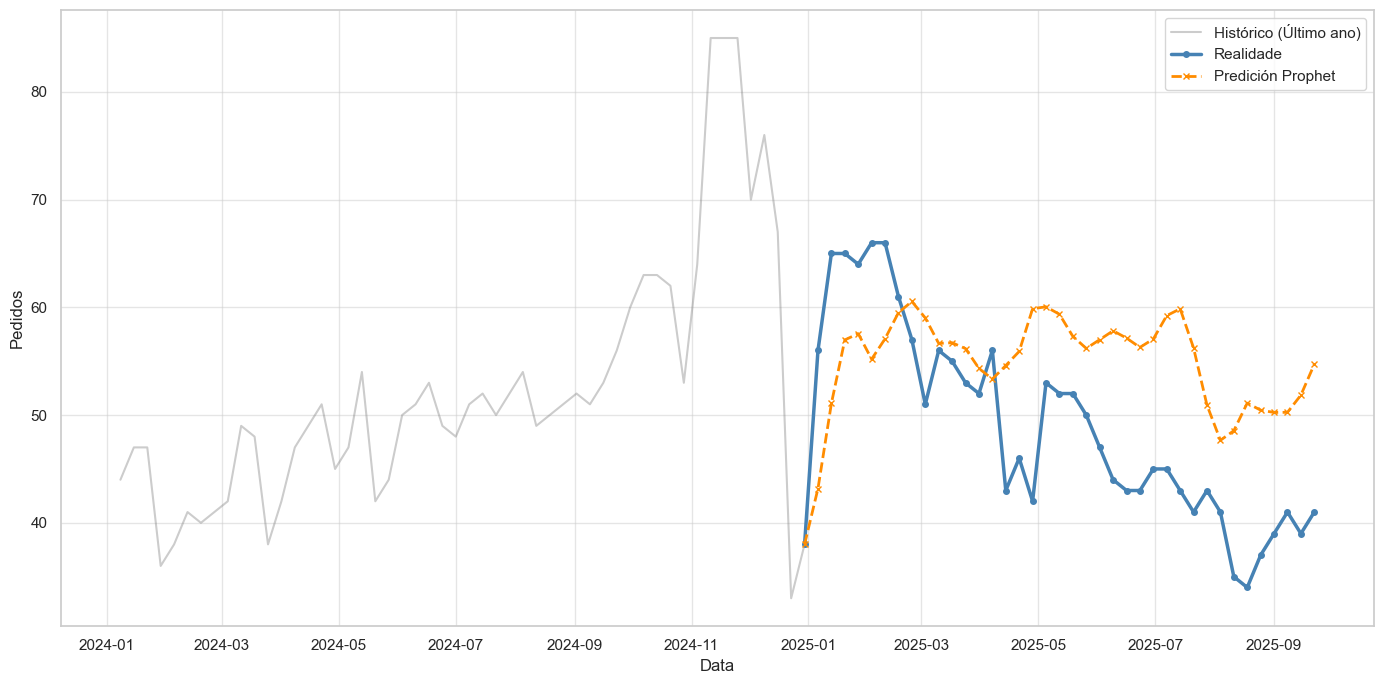

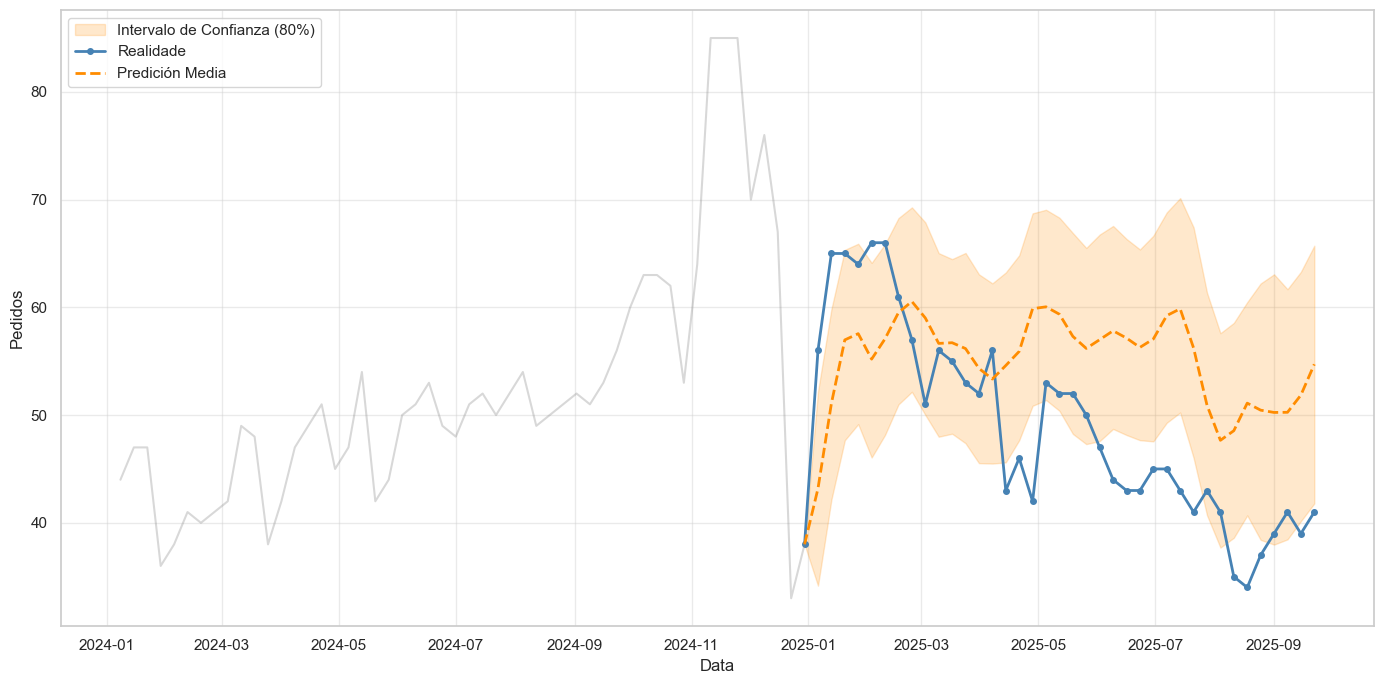

In [111]:
print(f"\n--- ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade 
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza 
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [112]:
# Cálculo de Métricas 
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Cluster 2 ---
MAE:  9.61
RMSE: 10.70
MAPE: 21.34%
MASE: 0.66 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


19:31:49 - cmdstanpy - INFO - Chain [1] start processing
19:31:49 - cmdstanpy - INFO - Chain [1] done processing


   Xerando compoñentes...


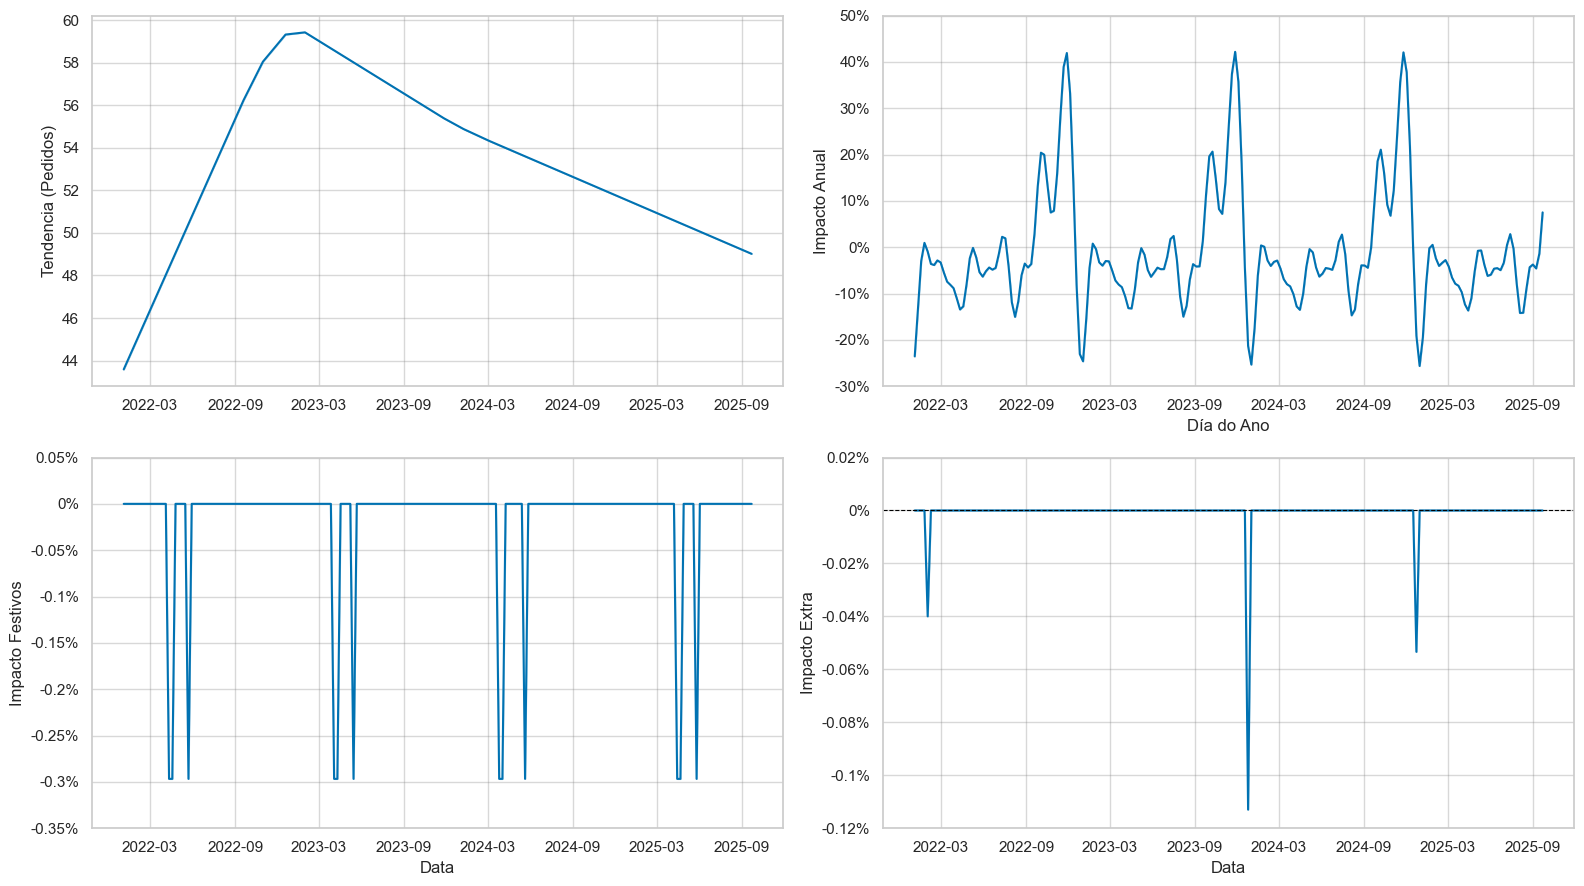

In [113]:
# Compoñentes 
print("   Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), 
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=""
)

### Cluster 3

Por último, axustamos os modelos Prophet ao noso último cluster, que contén aos clientes de alimentación e industria:

In [114]:
modelo = 'Cluster 3'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario
print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 3
    Prophet Prep: Train=157, Test=38
    Regresores detectados (0): []...
   Variables exóxenas detectadas (0): []


In [115]:
print(f"\n--- TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.5, 0.8, 0.9], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario
print(f"   Mellores parámetros: {resultados_prophet[modelo]['params']}")

19:31:59 - cmdstanpy - INFO - Chain [1] start processing
19:31:59 - cmdstanpy - INFO - Chain [1] done processing



--- TUNING: Cluster 3 ---
 Iniciando Grid Search con 48 combinacións...


19:32:00 - cmdstanpy - INFO - Chain [1] start processing
19:32:00 - cmdstanpy - INFO - Chain [1] start processing
19:32:00 - cmdstanpy - INFO - Chain [1] start processing
19:32:00 - cmdstanpy - INFO - Chain [1] start processing
19:32:00 - cmdstanpy - INFO - Chain [1] start processing
19:32:00 - cmdstanpy - INFO - Chain [1] start processing
19:32:01 - cmdstanpy - INFO - Chain [1] done processing
19:32:01 - cmdstanpy - INFO - Chain [1] done processing
19:32:01 - cmdstanpy - INFO - Chain [1] done processing
19:32:01 - cmdstanpy - INFO - Chain [1] done processing
19:32:01 - cmdstanpy - INFO - Chain [1] done processing
19:32:01 - cmdstanpy - INFO - Chain [1] done processing
19:32:01 - cmdstanpy - INFO - Chain [1] start processing
19:32:01 - cmdstanpy - INFO - Chain [1] done processing
19:32:02 - cmdstanpy - INFO - Chain [1] start processing
19:32:03 - cmdstanpy - INFO - Chain [1] start processing
19:32:03 - cmdstanpy - INFO - Chain [1] start processing
19:32:03 - cmdstanpy - INFO - Chain [1

   > Combinación 5/48: RMSE=6.1089


19:32:11 - cmdstanpy - INFO - Chain [1] start processing
19:32:11 - cmdstanpy - INFO - Chain [1] start processing
19:32:11 - cmdstanpy - INFO - Chain [1] start processing
19:32:11 - cmdstanpy - INFO - Chain [1] start processing
19:32:11 - cmdstanpy - INFO - Chain [1] start processing
19:32:11 - cmdstanpy - INFO - Chain [1] start processing
19:32:11 - cmdstanpy - INFO - Chain [1] done processing
19:32:11 - cmdstanpy - INFO - Chain [1] done processing
19:32:11 - cmdstanpy - INFO - Chain [1] done processing
19:32:11 - cmdstanpy - INFO - Chain [1] done processing
19:32:11 - cmdstanpy - INFO - Chain [1] done processing
19:32:12 - cmdstanpy - INFO - Chain [1] done processing
19:32:12 - cmdstanpy - INFO - Chain [1] start processing
19:32:12 - cmdstanpy - INFO - Chain [1] done processing
19:32:14 - cmdstanpy - INFO - Chain [1] start processing
19:32:14 - cmdstanpy - INFO - Chain [1] done processing
19:32:14 - cmdstanpy - INFO - Chain [1] start processing
19:32:14 - cmdstanpy - INFO - Chain [1]

...

19:33:45 - cmdstanpy - INFO - Chain [1] done processing
19:33:46 - cmdstanpy - INFO - Chain [1] start processing
19:33:46 - cmdstanpy - INFO - Chain [1] start processing
19:33:46 - cmdstanpy - INFO - Chain [1] start processing
19:33:46 - cmdstanpy - INFO - Chain [1] start processing
19:33:47 - cmdstanpy - INFO - Chain [1] start processing
19:33:47 - cmdstanpy - INFO - Chain [1] start processing
19:33:47 - cmdstanpy - INFO - Chain [1] done processing
19:33:47 - cmdstanpy - INFO - Chain [1] done processing
19:33:47 - cmdstanpy - INFO - Chain [1] done processing
19:33:47 - cmdstanpy - INFO - Chain [1] done processing
19:33:47 - cmdstanpy - INFO - Chain [1] done processing
19:33:48 - cmdstanpy - INFO - Chain [1] done processing
19:33:48 - cmdstanpy - INFO - Chain [1] start processing
19:33:48 - cmdstanpy - INFO - Chain [1] done processing
19:33:50 - cmdstanpy - INFO - Chain [1] start processing
19:33:50 - cmdstanpy - INFO - Chain [1] start processing
19:33:50 - cmdstanpy - INFO - Chain [1]

   > Combinación 45/48: RMSE=6.2490


19:34:00 - cmdstanpy - INFO - Chain [1] done processing
19:34:02 - cmdstanpy - INFO - Chain [1] start processing
19:34:02 - cmdstanpy - INFO - Chain [1] start processing
19:34:02 - cmdstanpy - INFO - Chain [1] start processing
19:34:02 - cmdstanpy - INFO - Chain [1] start processing
19:34:02 - cmdstanpy - INFO - Chain [1] start processing
19:34:02 - cmdstanpy - INFO - Chain [1] start processing
19:34:02 - cmdstanpy - INFO - Chain [1] done processing
19:34:02 - cmdstanpy - INFO - Chain [1] done processing
19:34:02 - cmdstanpy - INFO - Chain [1] done processing
19:34:02 - cmdstanpy - INFO - Chain [1] done processing
19:34:02 - cmdstanpy - INFO - Chain [1] done processing
19:34:03 - cmdstanpy - INFO - Chain [1] done processing
19:34:03 - cmdstanpy - INFO - Chain [1] start processing
19:34:03 - cmdstanpy - INFO - Chain [1] done processing
19:34:05 - cmdstanpy - INFO - Chain [1] start processing
19:34:05 - cmdstanpy - INFO - Chain [1] start processing
19:34:05 - cmdstanpy - INFO - Chain [1]


 Grid Search Completado.
   Mellor RMSE: 5.7767
   Parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}
   Mellores parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}


19:34:09 - cmdstanpy - INFO - Chain [1] done processing


In [116]:
print(f"\n---  ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'],
    verbose=True
)

19:34:14 - cmdstanpy - INFO - Chain [1] start processing
19:34:14 - cmdstanpy - INFO - Chain [1] done processing
19:34:14 - cmdstanpy - INFO - Chain [1] start processing
19:34:14 - cmdstanpy - INFO - Chain [1] done processing
19:34:14 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing



---  ROLLING WINDOW: Cluster 3 ---
 Iniciando Prophet Rolling Window (38 pasos)...


19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1] done processing
19:34:15 - cmdstanpy - INFO - Chain [1] start processing
19:34:15 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=27.23


19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1]

   > Semana 20/38: Pred=17.25


19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:16 - cmdstanpy - INFO - Chain [1] done processing
19:34:16 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=19.15


19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing
19:34:17 - cmdstanpy - INFO - Chain [1] start processing
19:34:17 - cmdstanpy - INFO - Chain [1] done processing



---  ANÁLISE GRÁFICA: Cluster 3 ---


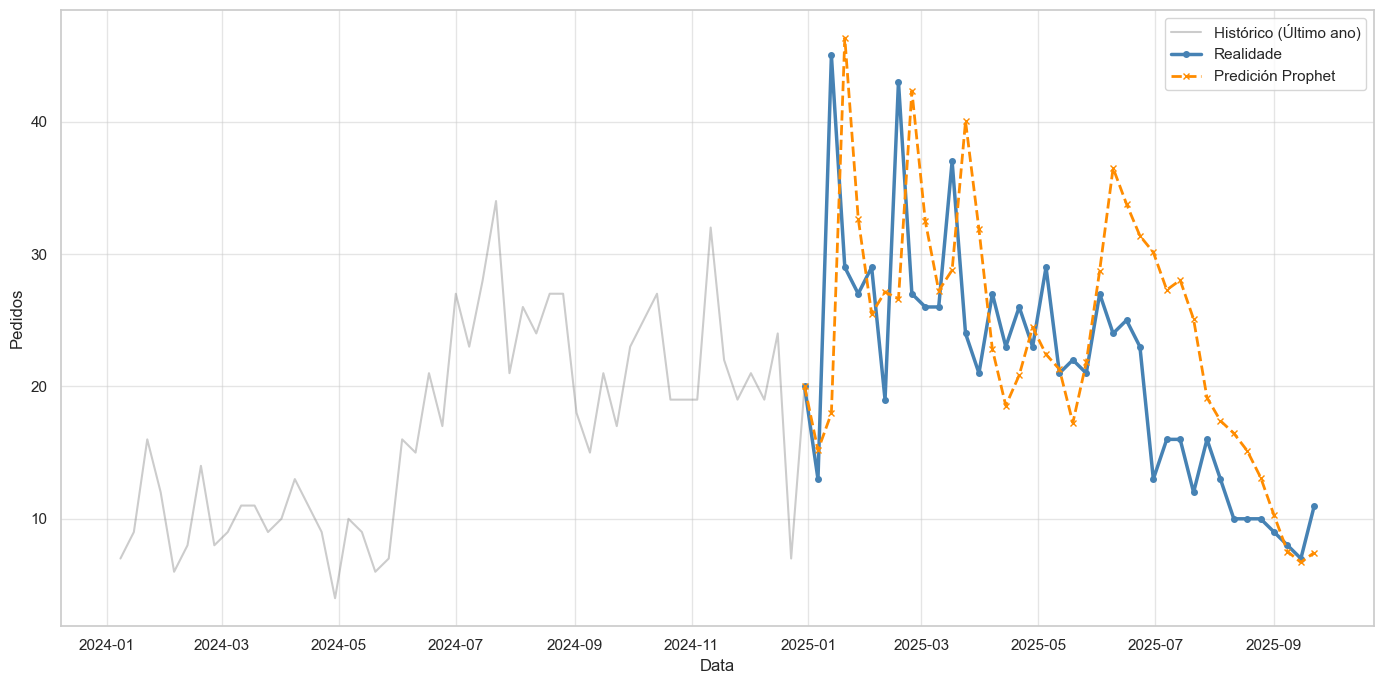

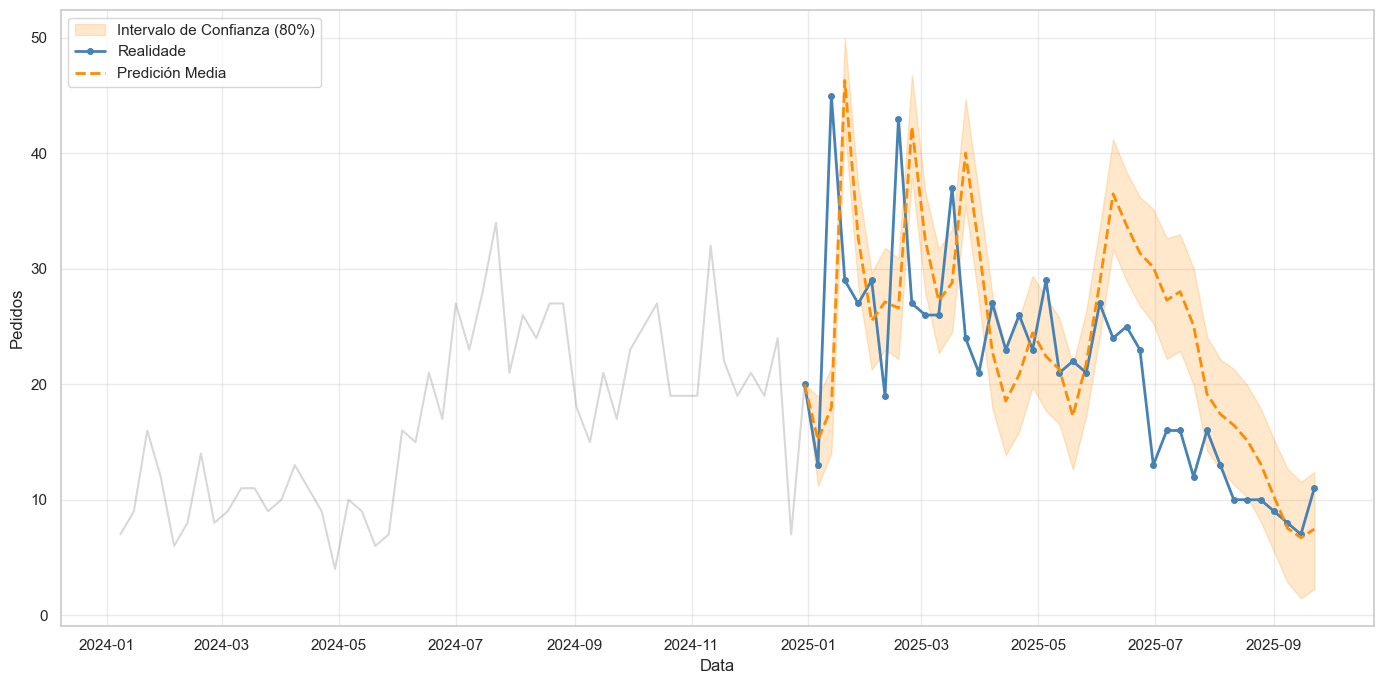

In [117]:
print(f"\n---  ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade 
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza 
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [118]:
# Cálculo de Métricas
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Cluster 3 ---
MAE:  7.34
RMSE: 9.50
MAPE: 35.84%
MASE: 0.97 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos como o MAPE é relativamente elevado (35.84 %), por estar avaliando valores baixos (erros de apenas 6 pedidos son tan significativos). Porén, vemos un mellor comportamento do modelo fronte ao preditor naïve estacional (MASE = 0.97).

19:34:24 - cmdstanpy - INFO - Chain [1] start processing
19:34:24 - cmdstanpy - INFO - Chain [1] done processing


   Xerando compoñentes...


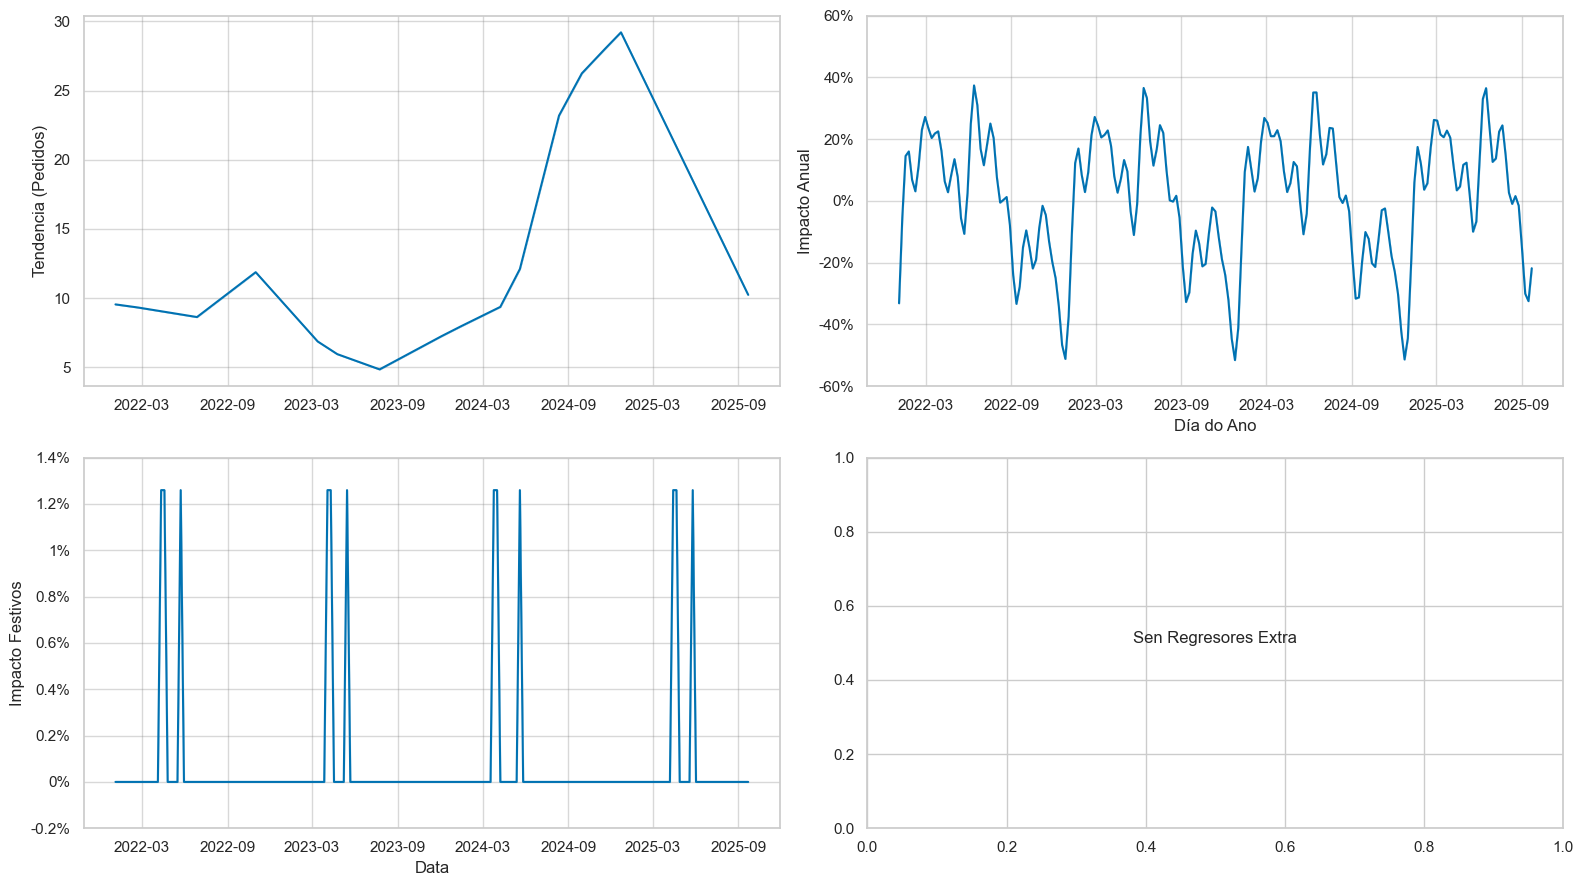

In [119]:
# Compoñentes 
print("   Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), 
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=""
)